In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

# Define the folder path where your CSV files are stored
folder_path = '/content/drive/My Drive/Dataset/'

# List files in the folder to verify they exist
print("Files in the folder:", os.listdir(folder_path))

def detect_date_column(df):
    """
    Detects a date column (case-insensitive) in a DataFrame.
    Looks for 'date' or 'observation_date'.
    Raises a ValueError if no such column exists.
    """
    possible_date_columns = ['date', 'observation_date']
    for col in df.columns:
        if col.strip().lower() in possible_date_columns:
            return col
    raise ValueError("No date column found in the dataset.")

def read_dataset(filename):
    """
    Loads a CSV file, converts its date column to datetime,
    and sets it as the index.

    Args:
        filename (str): Name of the CSV file.

    Returns:
        pd.DataFrame: Processed DataFrame with a DatetimeIndex.
    """
    full_path = os.path.join(folder_path, filename)
    df = pd.read_csv(full_path)

    try:
        date_col = detect_date_column(df)
    except ValueError as e:
        raise ValueError(f"Error in file '{filename}': {e}")

    # Convert the detected date column to datetime (coerce errors)
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    if df[date_col].isnull().all():
        raise ValueError(f"Date conversion failed for column '{date_col}' in file '{filename}'.")

    # Set the date column as the index
    df.set_index(date_col, inplace=True)

    # Verify the index is a DatetimeIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError(f"Index for file '{filename}' is not a DatetimeIndex after conversion.")

    return df

# List of CSV filenames to load (no renaming dictionaries needed)
filenames = [
    'T10YIE.csv',
    'T5YIFR.csv',
    'CPIAUCNS.csv',
    'GDPC1.csv',
    'UNRATE.csv',
    'FEDFUNDS.csv',
    'PCEPI.csv',
    'DTWEXBGS.csv',
    'DCOILWTICO.csv',
    'DGS10.csv'
]

# Load each dataset; skip files with errors.
datasets = []
for filename in filenames:
    try:
        temp_df = read_dataset(filename)
        datasets.append(temp_df)
    except Exception as e:
        print(f"Skipping file '{filename}' due to error: {e}")

if not datasets:
    raise ValueError("No datasets loaded successfully. Please check your files.")

# Resample each dataset to a daily frequency and forward-fill missing values
datasets = [df.asfreq('D').ffill() for df in datasets]

# Determine the common date range across all datasets:
#   - New dataset starting point: the newest (maximum) start date among datasets
#   - New dataset ending point: the oldest (minimum) end date among datasets
start_dates = [df.index.min() for df in datasets]
end_dates   = [df.index.max() for df in datasets]

common_start = max(start_dates)
common_end   = min(end_dates)

if common_start > common_end:
    raise ValueError("No overlapping date range among datasets. Check your data.")

print("Common start date:", common_start)
print("Common end date:", common_end)

# Trim each dataset to the common date range
datasets = [df.loc[common_start:common_end] for df in datasets]

# Merge all datasets on the date index using an inner join (keeping only common dates)
df = pd.concat(datasets, axis=1, join='inner')

print("Merged dataset shape:", df.shape)

Mounted at /content/drive
Files in the folder: ['T10YIE.csv', 'T5YIFR.csv', 'CPIAUCNS.csv', 'PCEPI.csv', 'GDPC1.csv', 'UNRATE.csv', 'FEDFUNDS.csv', 'DGS10.csv', 'DTWEXBGS.csv', 'DCOILWTICO.csv', 'merged_dataset.csv']
Common start date: 2006-01-02 00:00:00
Common end date: 2024-10-01 00:00:00
Merged dataset shape: (6848, 10)


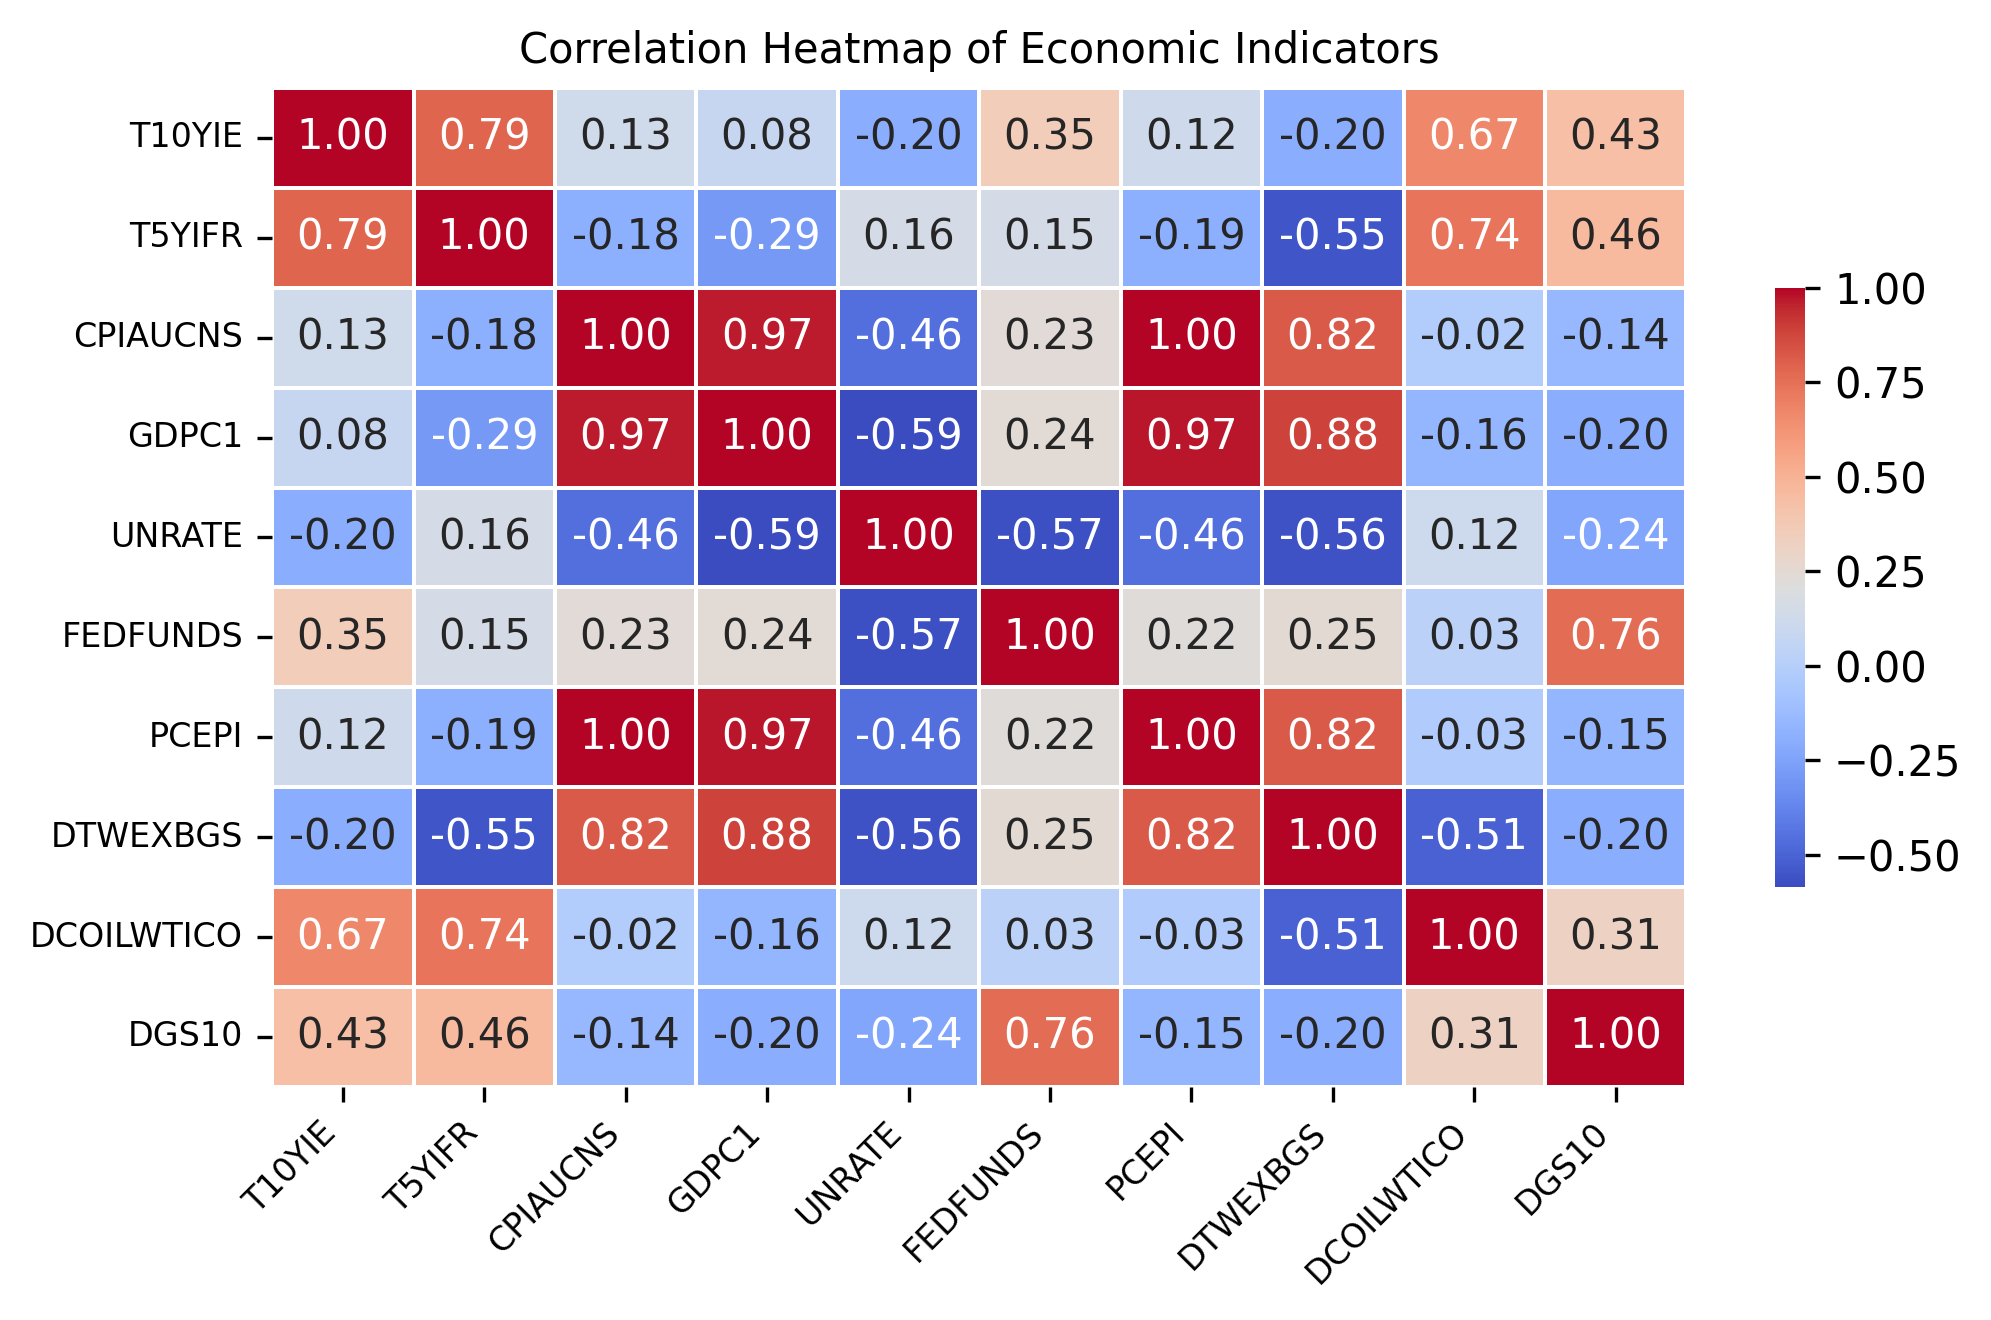

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap (journal-friendly format)
plt.figure(figsize=(7, 4.5), dpi=300)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar_kws={'shrink': 0.6})
plt.title("Correlation Heatmap of Economic Indicators", fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
target = "T10YIE"

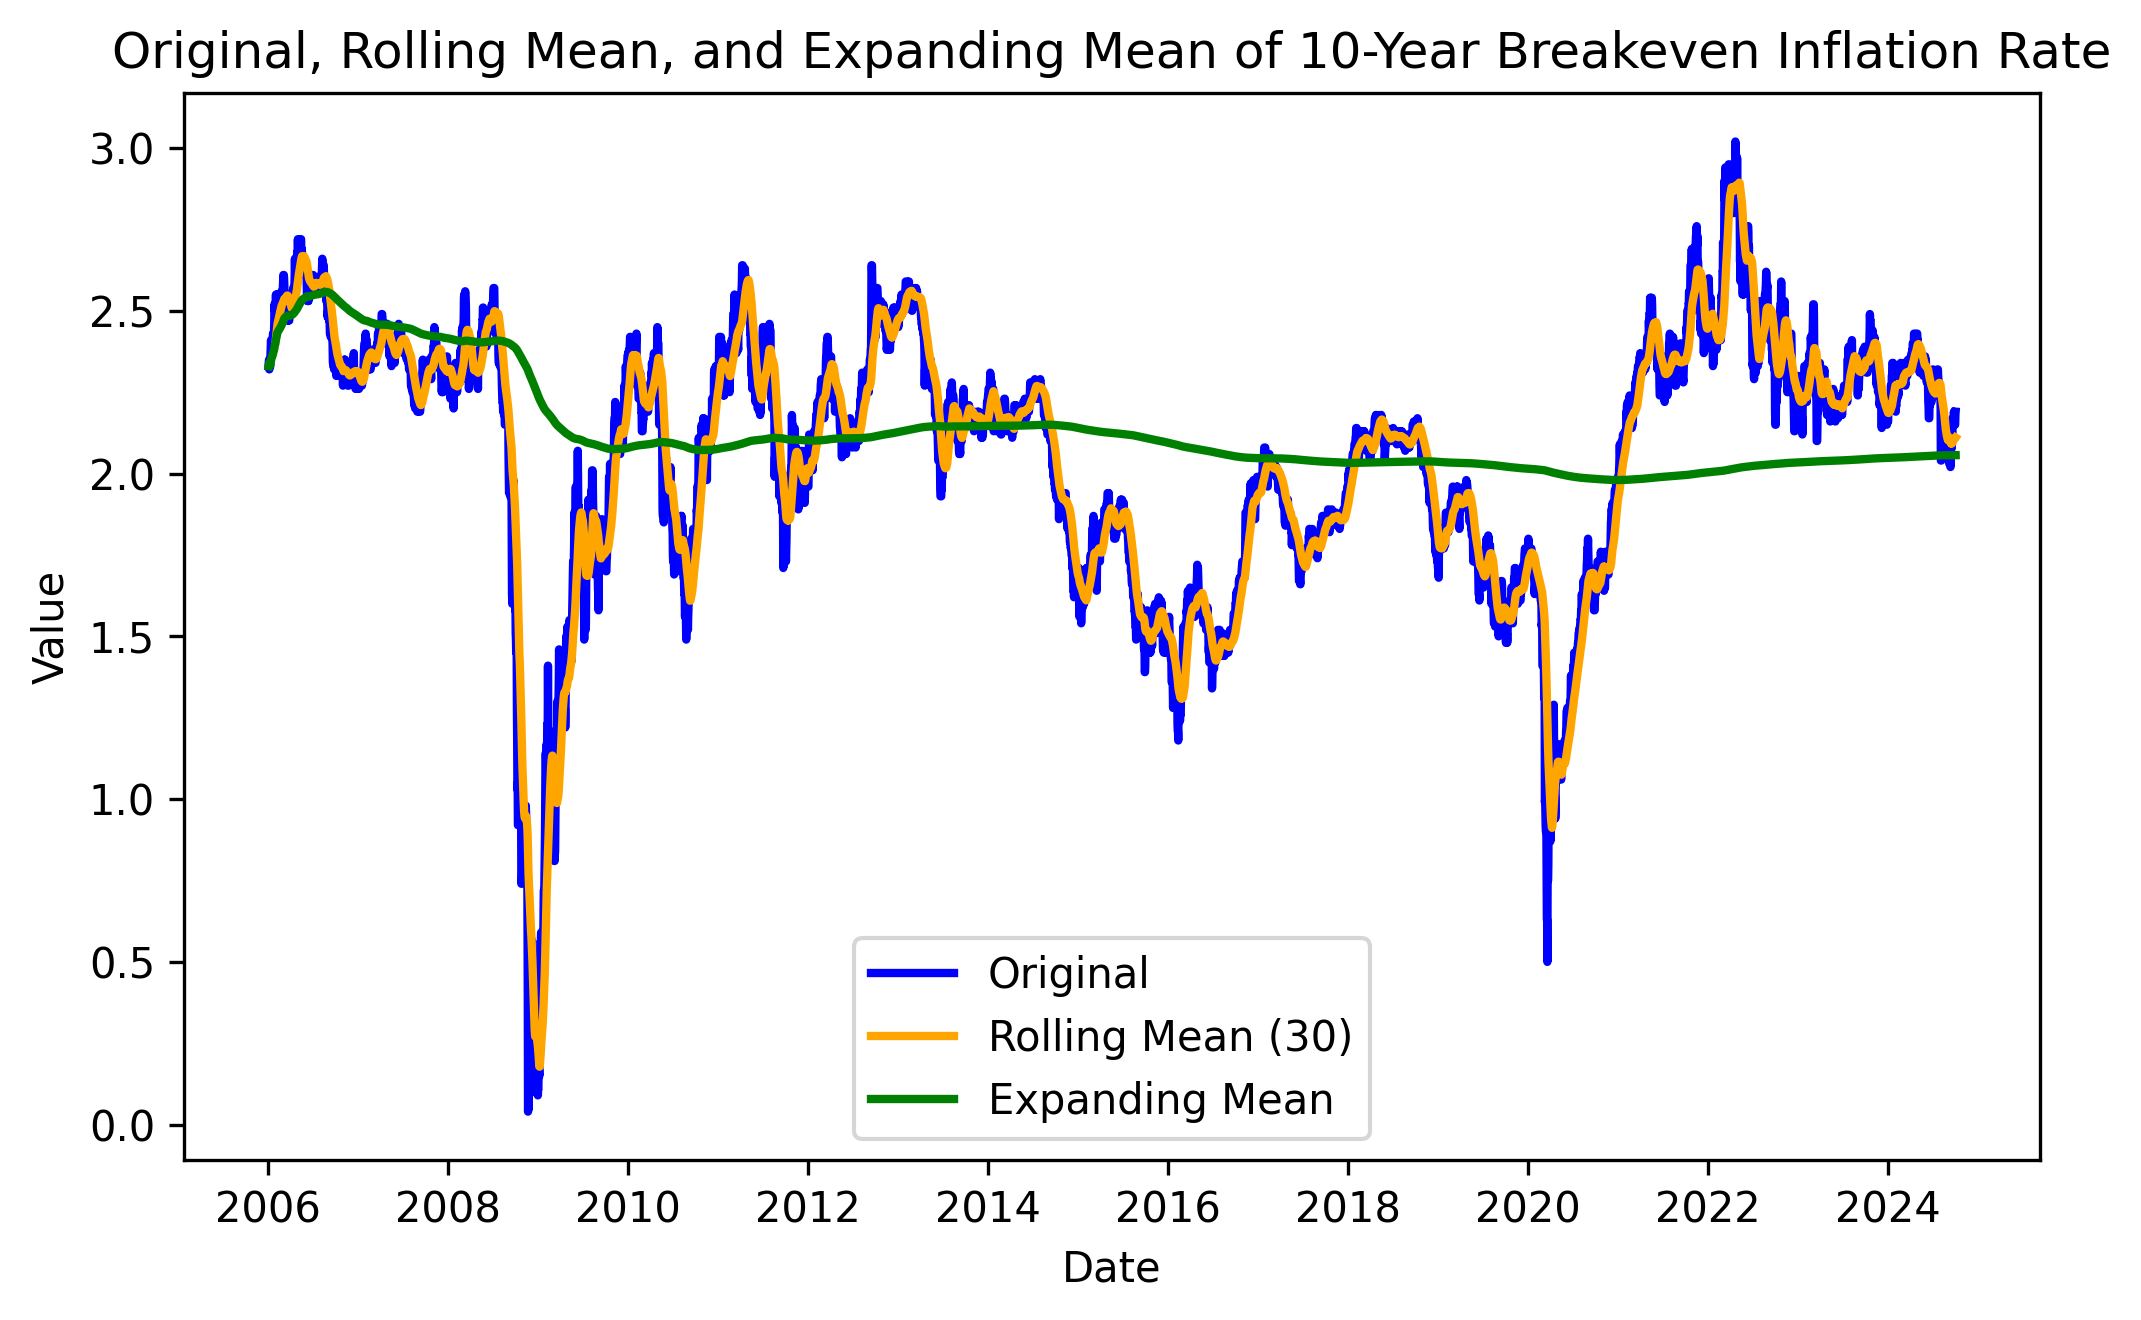

In [ ]:
import matplotlib.pyplot as plt

# Make sure 'target' is defined as the name of the column you're analyzing in df.
rolling_window = 30  # adjust as needed

# Compute Rolling Mean (e.g., 30-day rolling mean) and Expanding Mean
df['Rolling Mean'] = df[target].rolling(window=rolling_window).mean()
df['Expanding Mean'] = df[target].expanding().mean()

# Plot Original, Rolling Mean, and Expanding Mean with specified figure size and dpi
plt.figure(figsize=(7, 4.5), dpi=300)
plt.plot(df.index, df[target], label='Original', color='blue', linewidth=2)
plt.plot(df.index, df['Rolling Mean'], label=f'Rolling Mean ({rolling_window})', color='orange', linewidth=2)
plt.plot(df.index, df['Expanding Mean'], label='Expanding Mean', color='green', linewidth=2)
plt.title("Original, Rolling Mean, and Expanding Mean of 10-Year Breakeven Inflation Rate")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


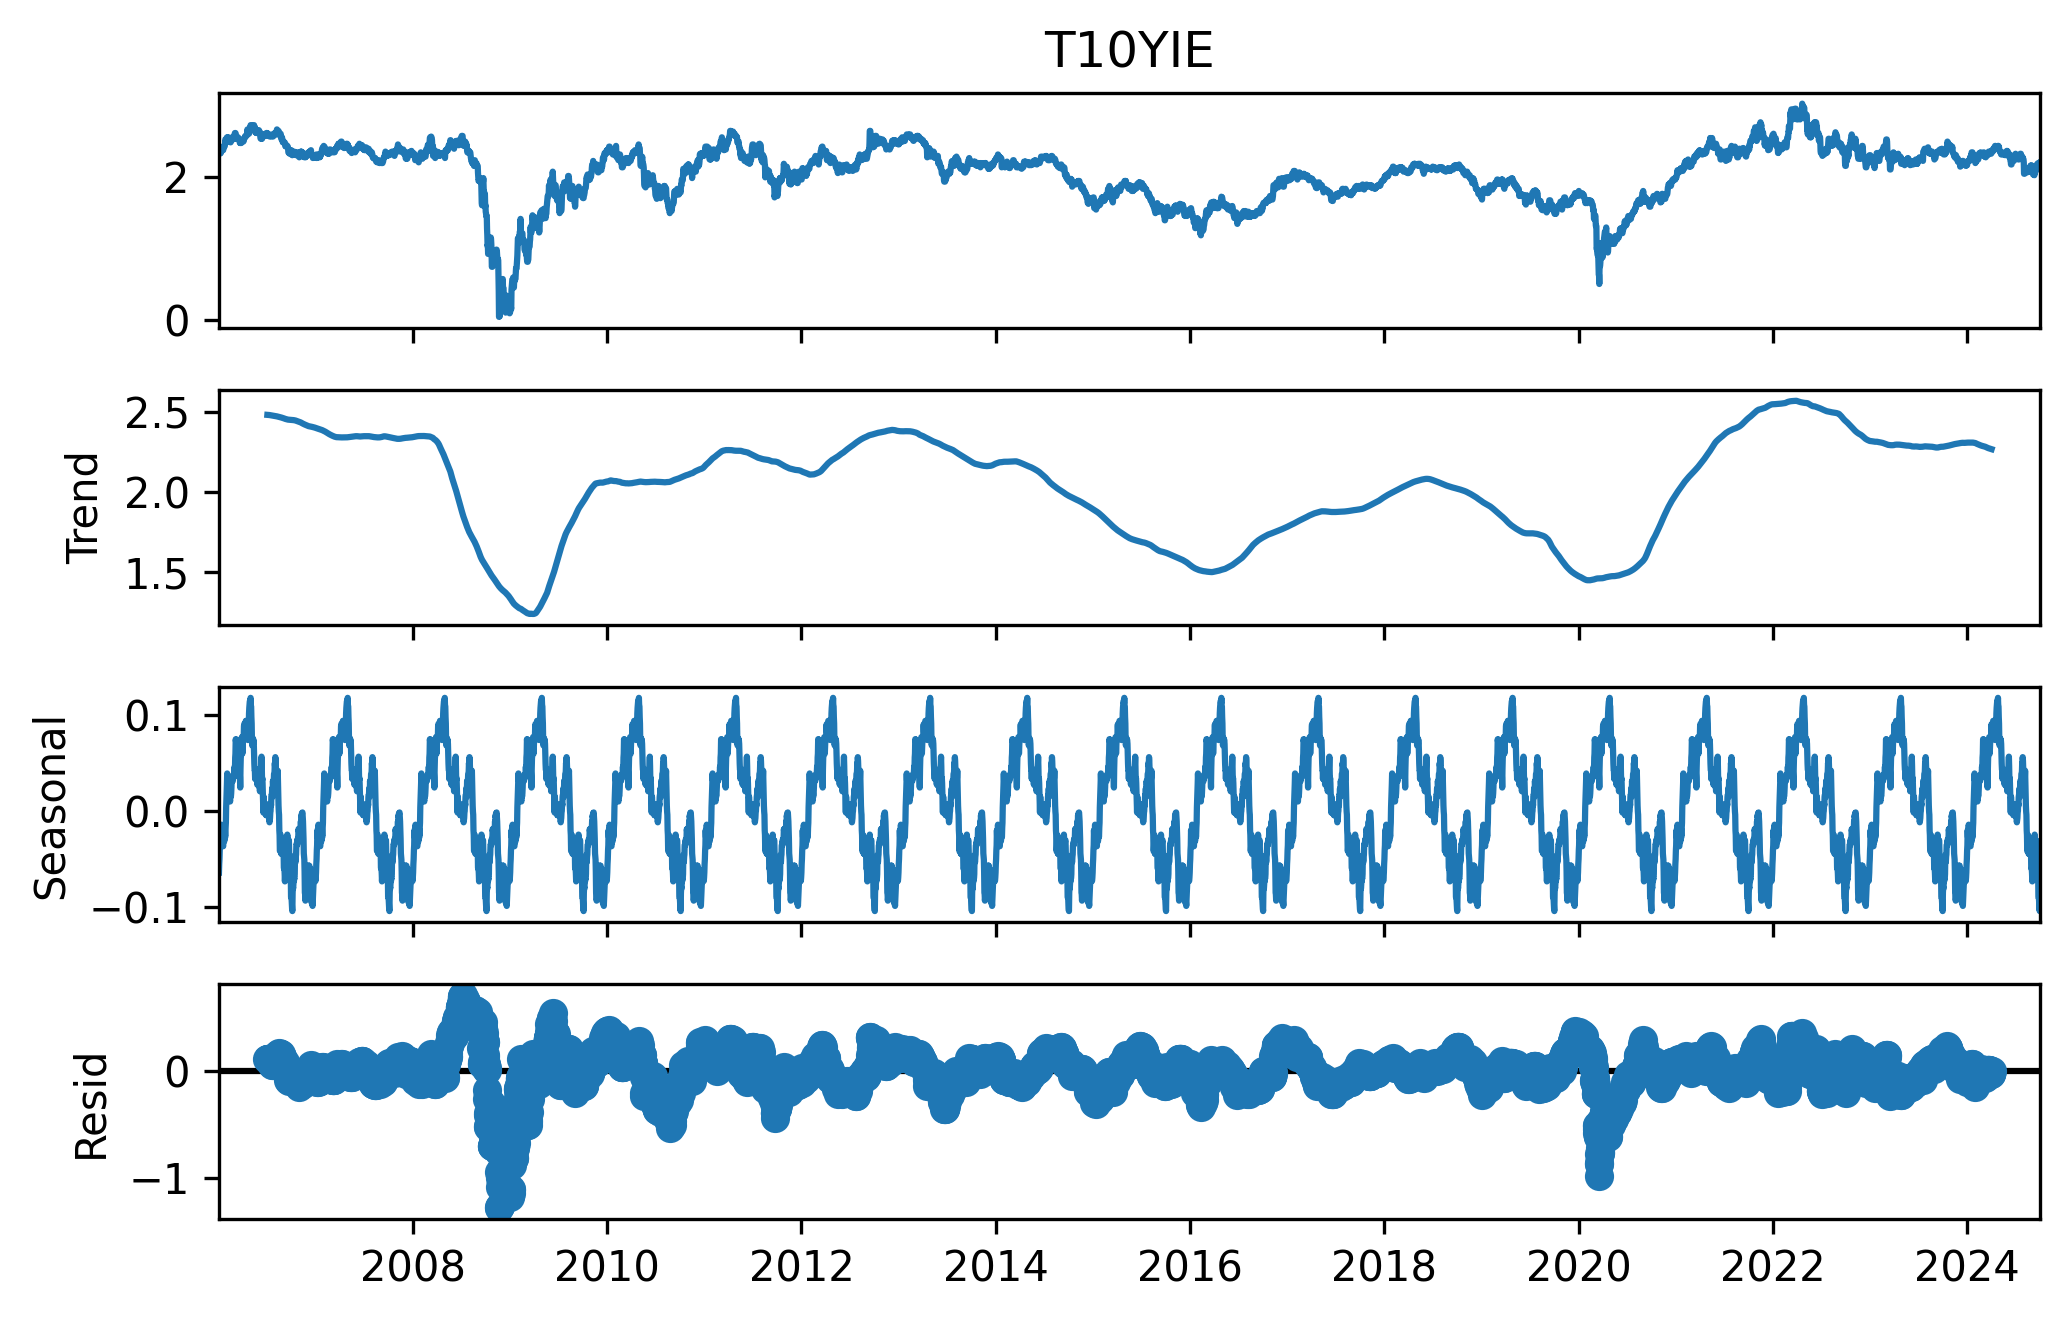

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series using an additive model.
# Adjust the period based on your data frequency (e.g., 365 for daily data with yearly seasonality)
decomposition = seasonal_decompose(df[target], model='additive', period=365)

# Plot the decomposition results
# The .plot() method returns a figure object, which we can then modify
fig = decomposition.plot()
fig.set_size_inches(7, 4.5)
fig.set_dpi(300)
plt.tight_layout()
plt.show()

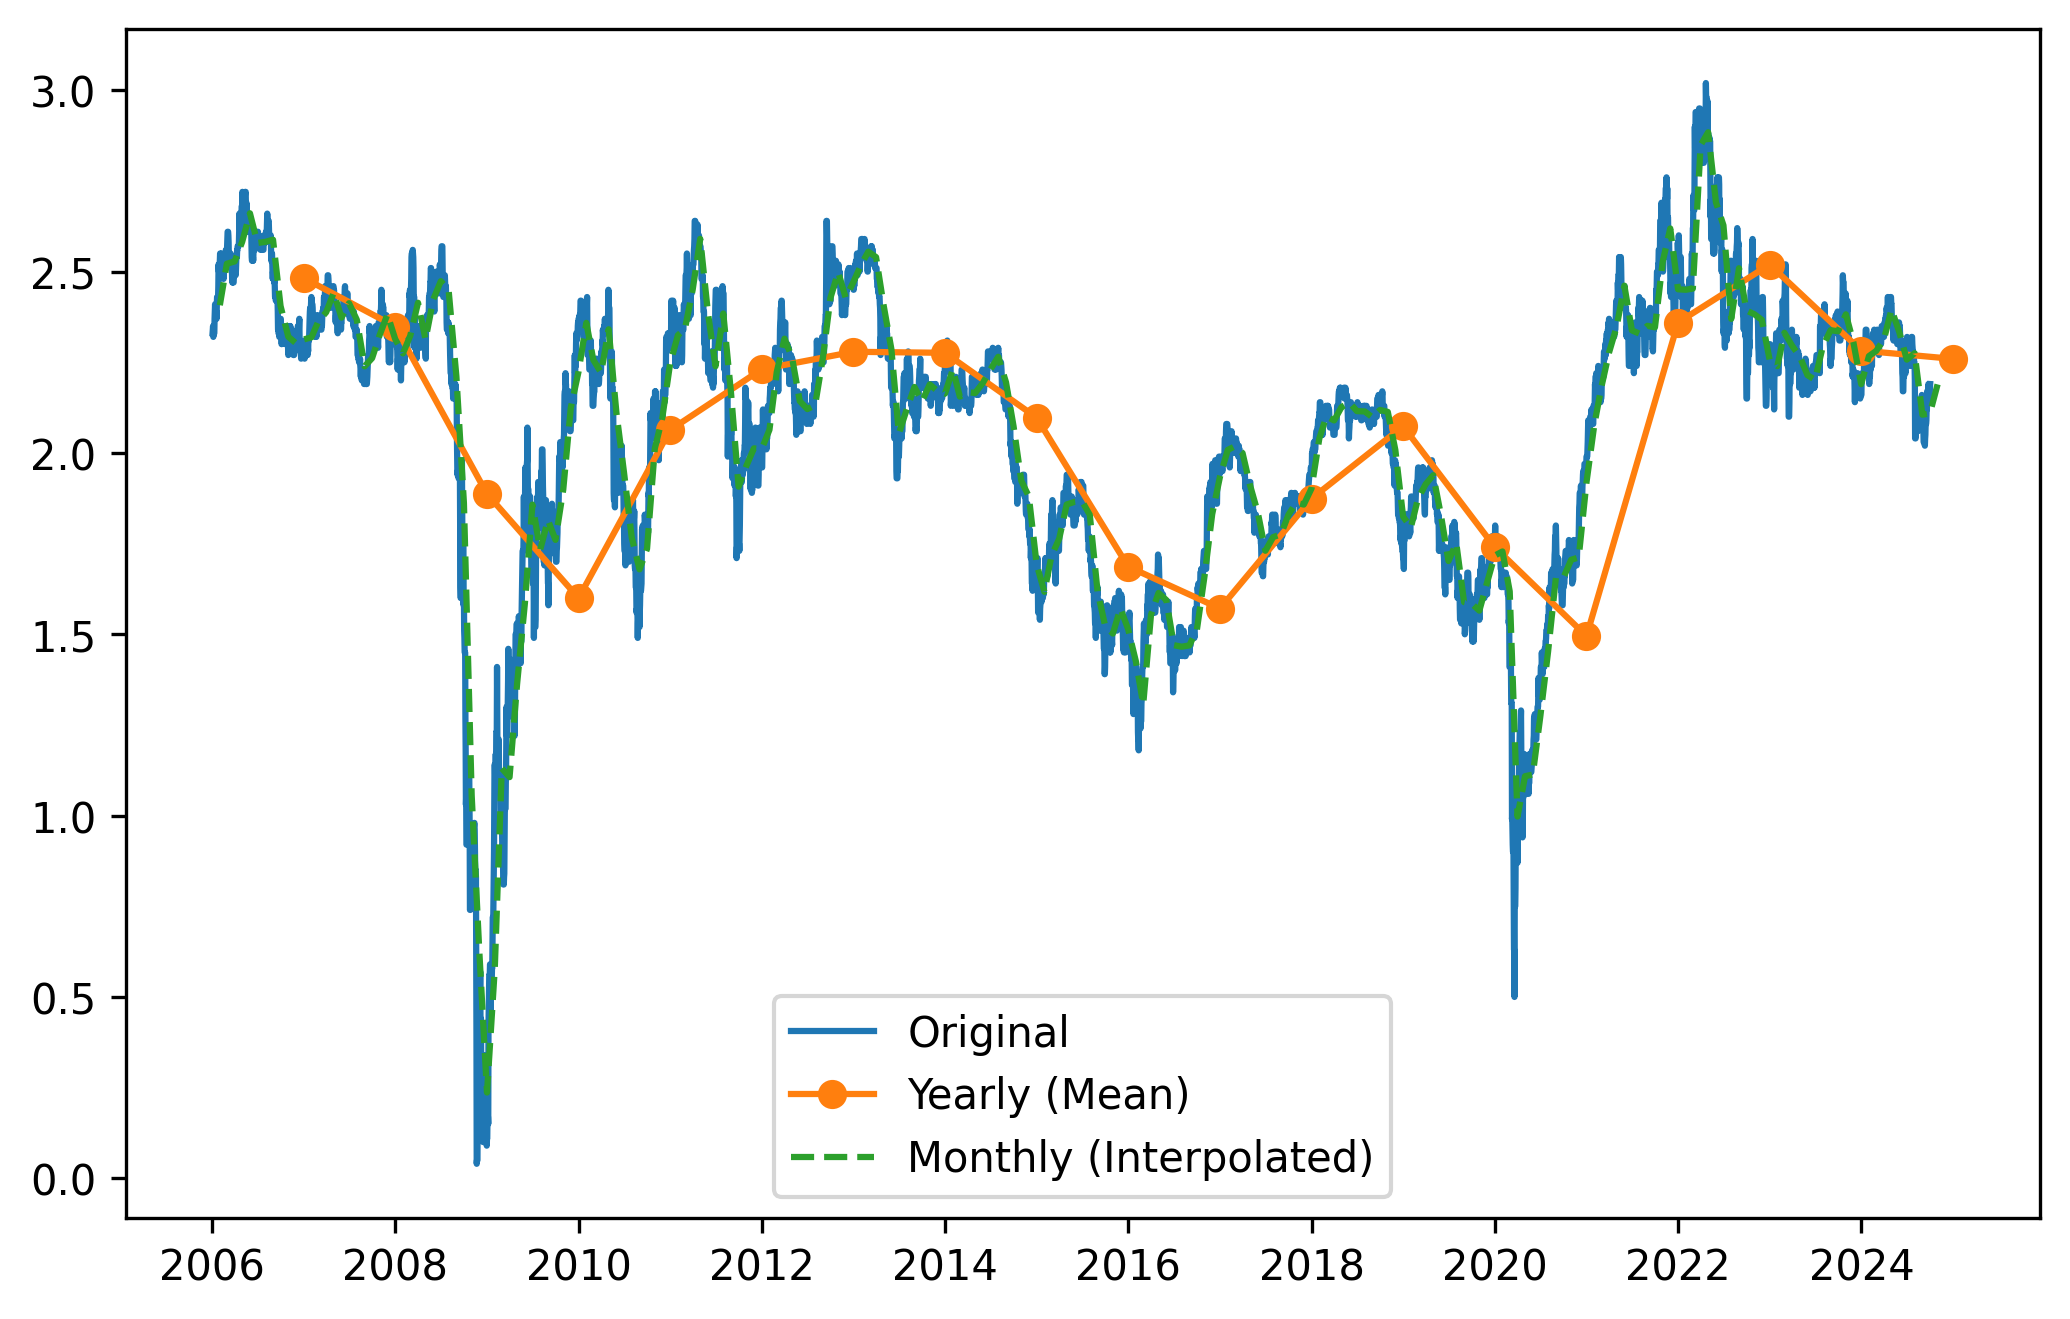

In [ ]:
import warnings
# Suppress all FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Downsample to yearly frequency using the mean
data_yearly = df.resample('Y').mean()

# Upsample to monthly frequency with interpolation
data_monthly = df.resample('M').mean().interpolate()

# (Optional) Plot to visualize the results with specified figure size and dpi
plt.figure(figsize=(7, 4.5), dpi=300)
plt.plot(df.index, df['T10YIE'], label='Original')
plt.plot(data_yearly.index, data_yearly['T10YIE'], 'o-', label='Yearly (Mean)')
plt.plot(data_monthly.index, data_monthly['T10YIE'], '--', label='Monthly (Interpolated)')
plt.legend()
plt.tight_layout()
plt.show()

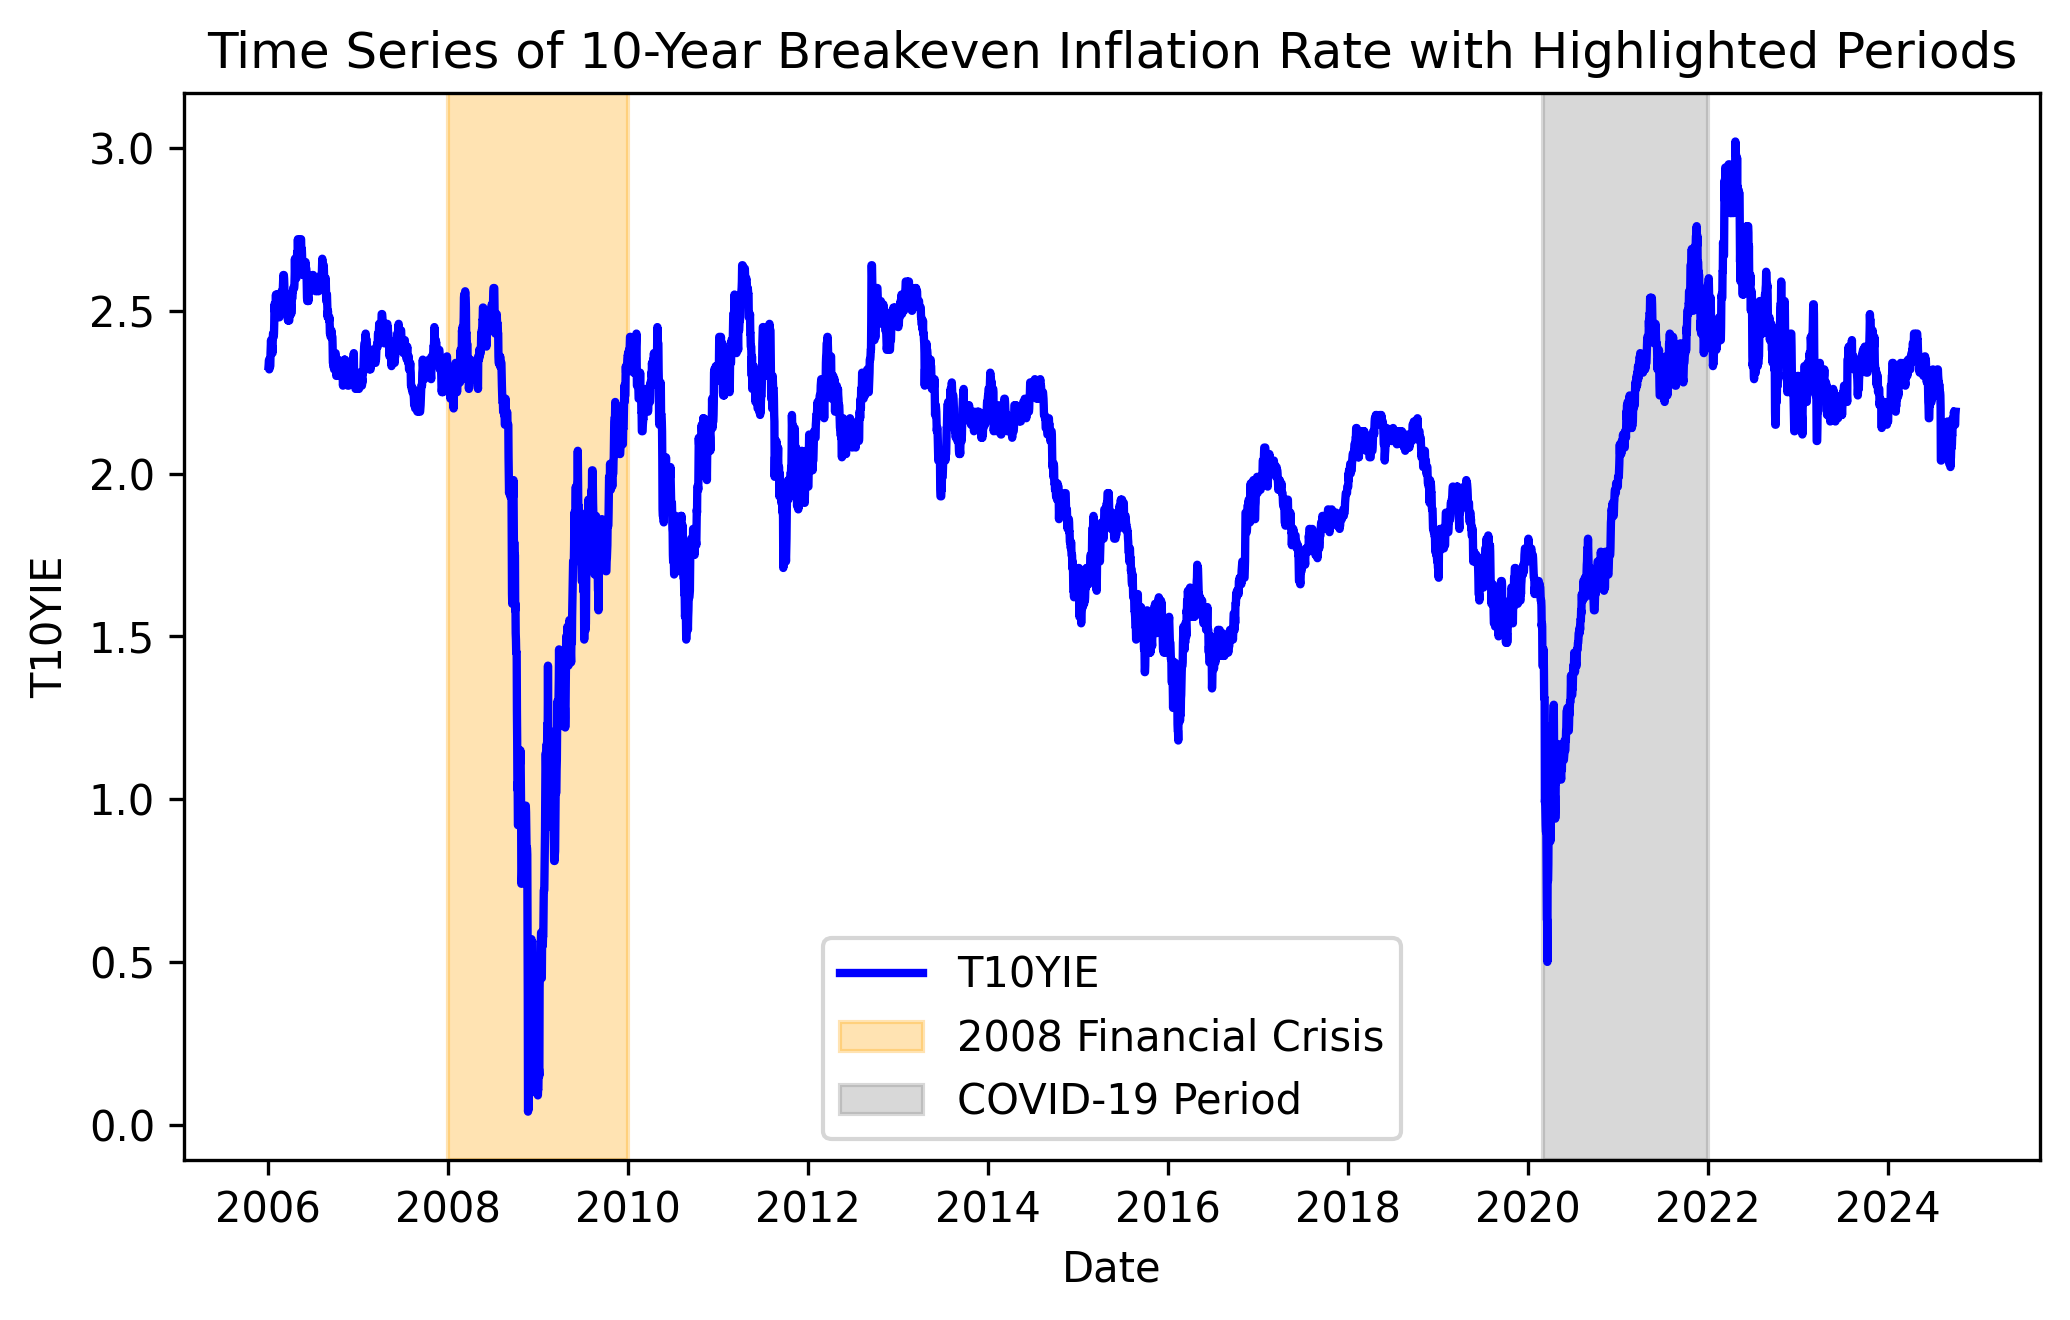

In [ ]:
# Plot the original time series with the specified figure size and dpi
plt.figure(figsize=(7, 4.5), dpi=300)
plt.plot(df.index, df[target], label=target, color='blue', linewidth=2)

# Highlight the 2008 Financial Crisis Period (e.g., Jan 2008 - Dec 2009)
plt.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-12-31'),
            color='orange', alpha=0.3, label='2008 Financial Crisis')

# Highlight the COVID-19 Period (e.g., Mar 2020 - Dec 2021)
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
            color='gray', alpha=0.3, label='COVID-19 Period')

plt.title("Time Series of 10-Year Breakeven Inflation Rate with Highlighted Periods")
plt.xlabel("Date")
plt.ylabel(target)
plt.legend()
plt.tight_layout()
plt.show()


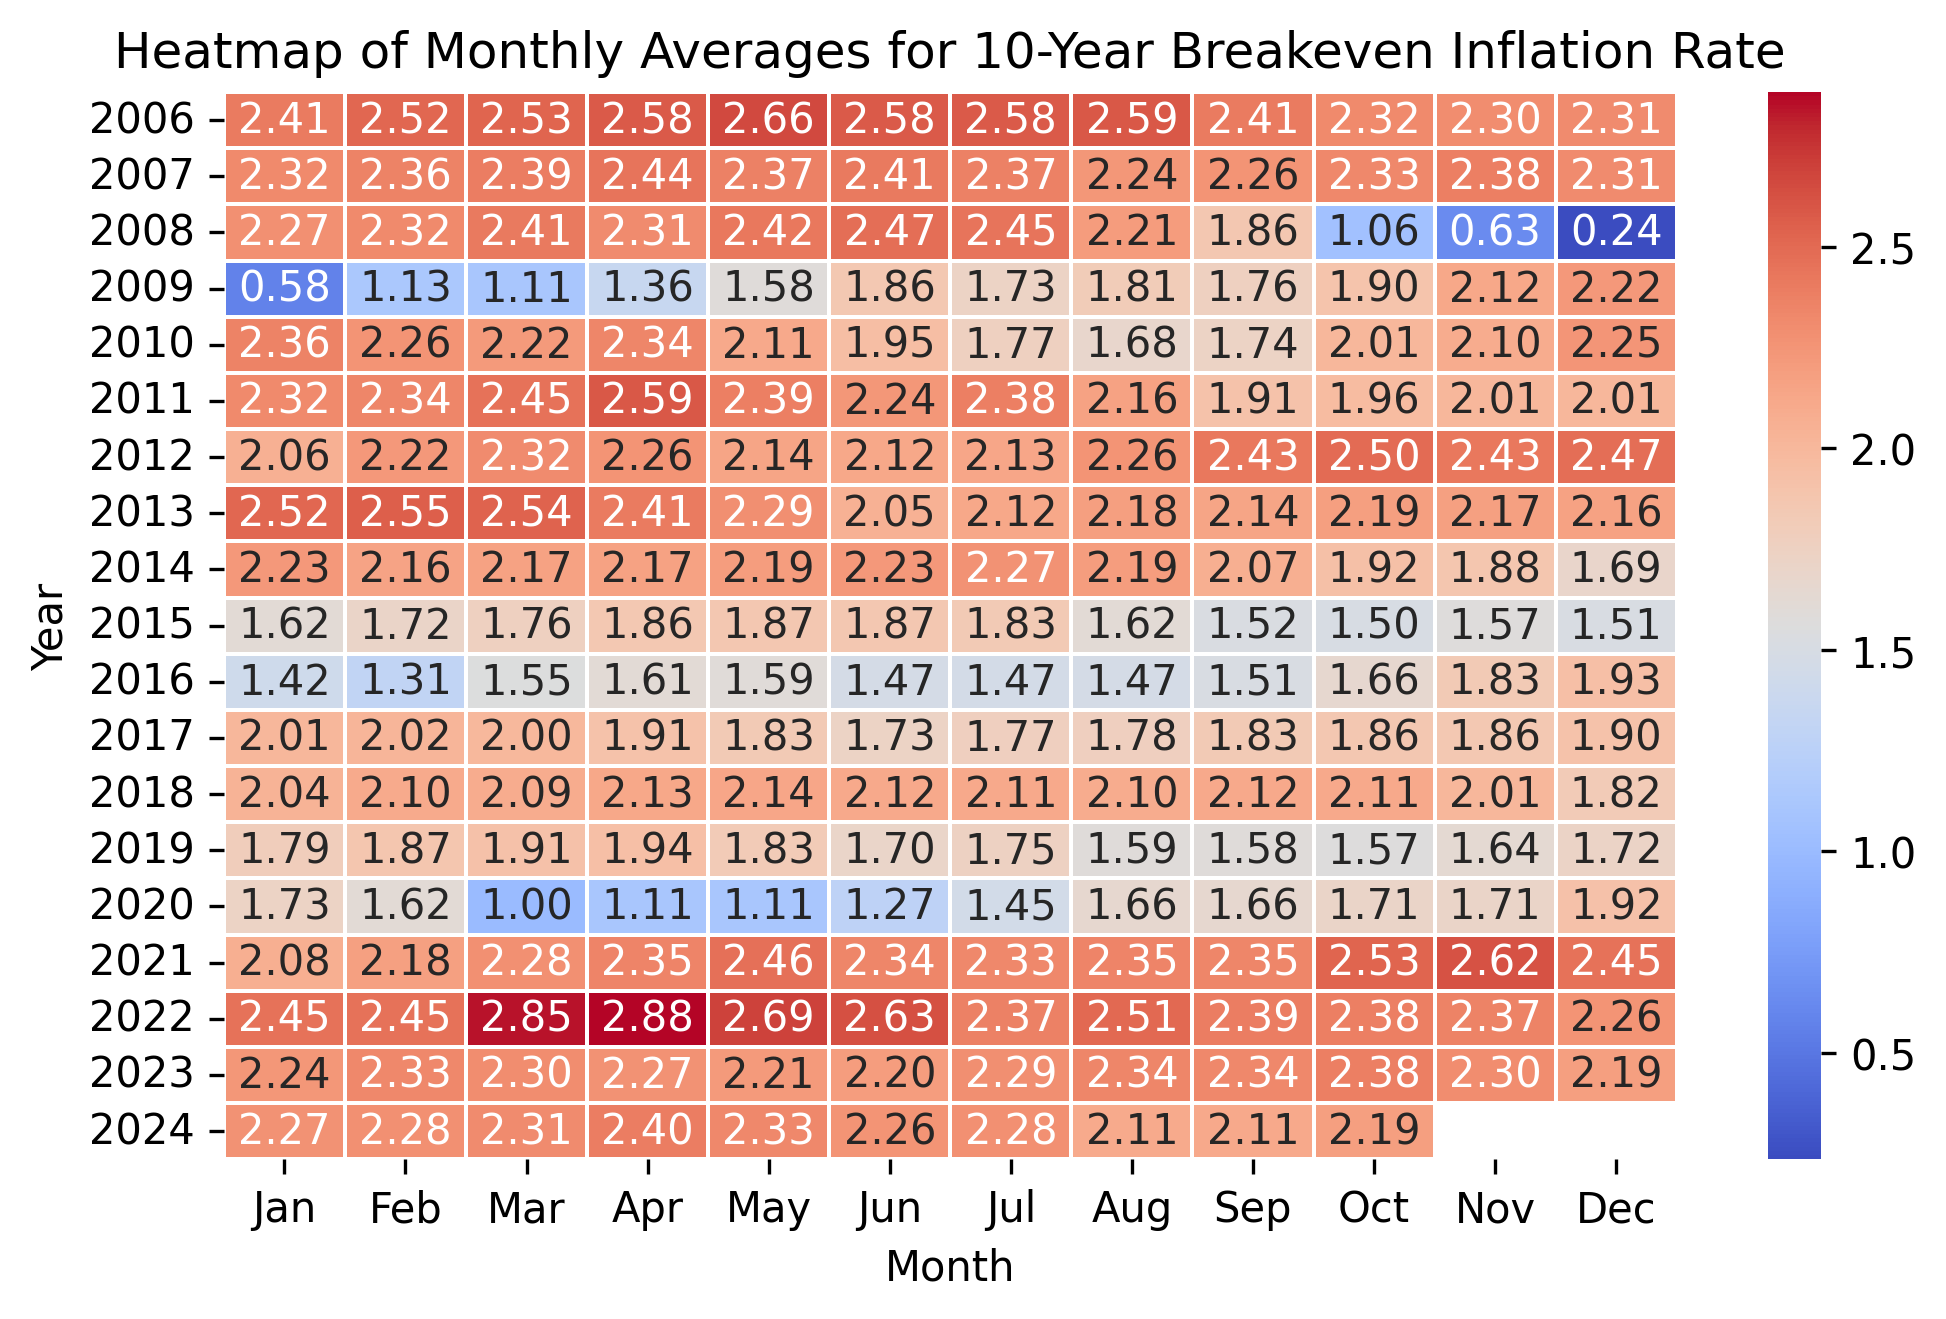

In [ ]:
import warnings
import calendar
import seaborn as sns
import matplotlib.pyplot as plt

# Suppress all FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Resample the data to monthly frequency using the mean
monthly_avg = df[target].resample('M').mean()

# Create a DataFrame with Year and Month columns
monthly_df = monthly_avg.to_frame(name=target)
monthly_df['Year'] = monthly_df.index.year
monthly_df['Month'] = monthly_df.index.month

# Pivot the data: rows = Year, columns = Month
pivot_table = monthly_df.pivot(index='Year', columns='Month', values=target)

# Optionally, map month numbers to month abbreviations for better readability
pivot_table.columns = [calendar.month_abbr[m] for m in pivot_table.columns]

# Plot the heatmap with the specified figure size and dpi
plt.figure(figsize=(7, 4.5), dpi=300)
sns.heatmap(pivot_table, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Monthly Averages for 10-Year Breakeven Inflation Rate")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

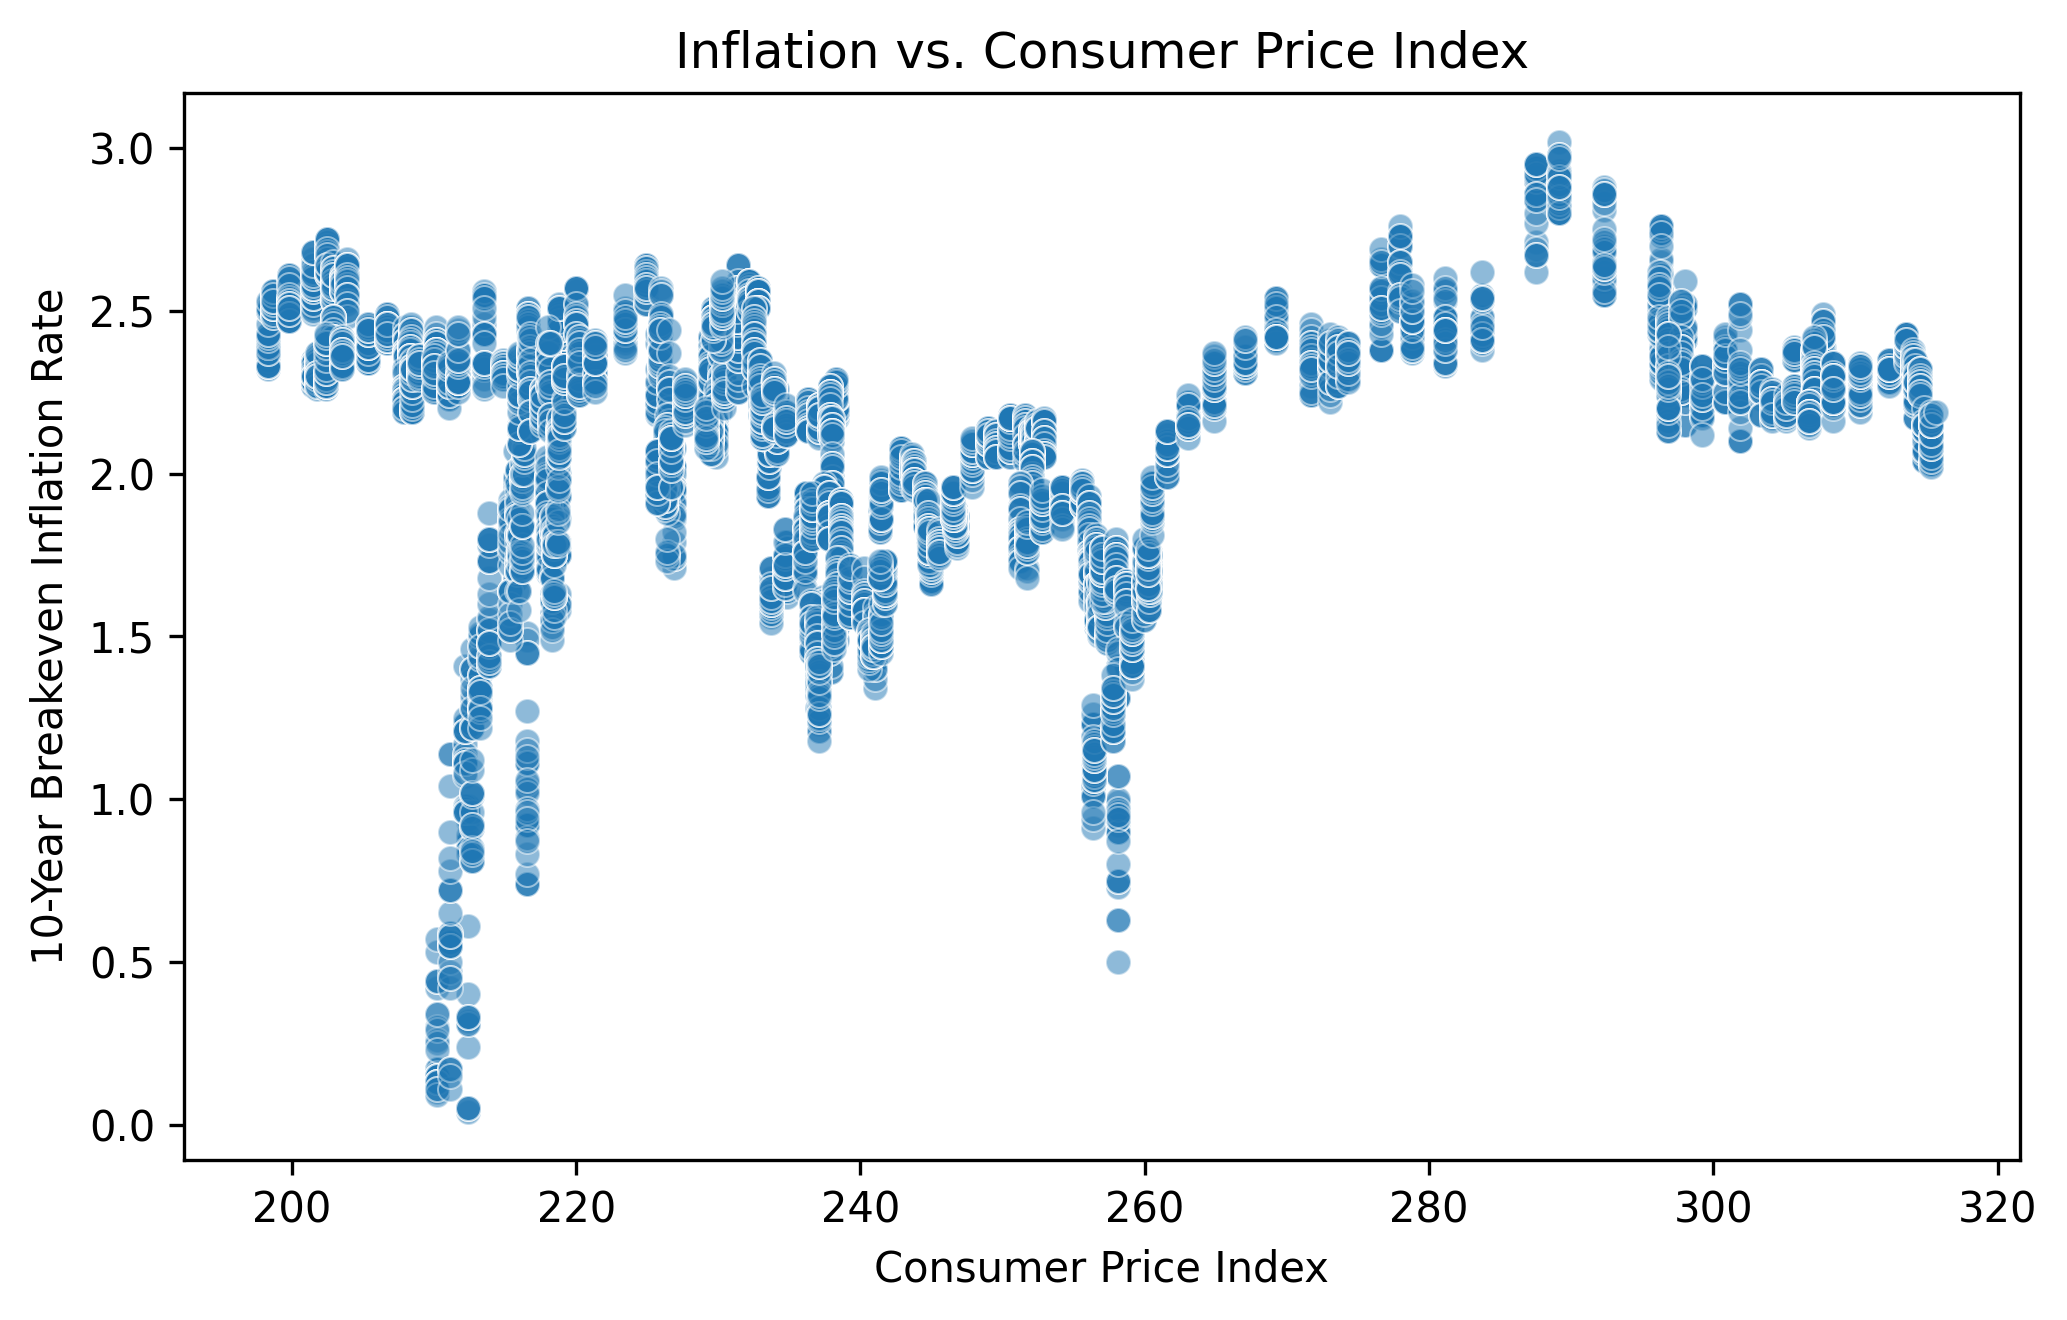

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4.5), dpi=300)
sns.scatterplot(x=df["CPIAUCNS"], y=df["T10YIE"], alpha=0.5)
plt.title("Inflation vs. Consumer Price Index")
plt.xlabel("Consumer Price Index")
plt.ylabel("10-Year Breakeven Inflation Rate")
plt.tight_layout()
plt.show()

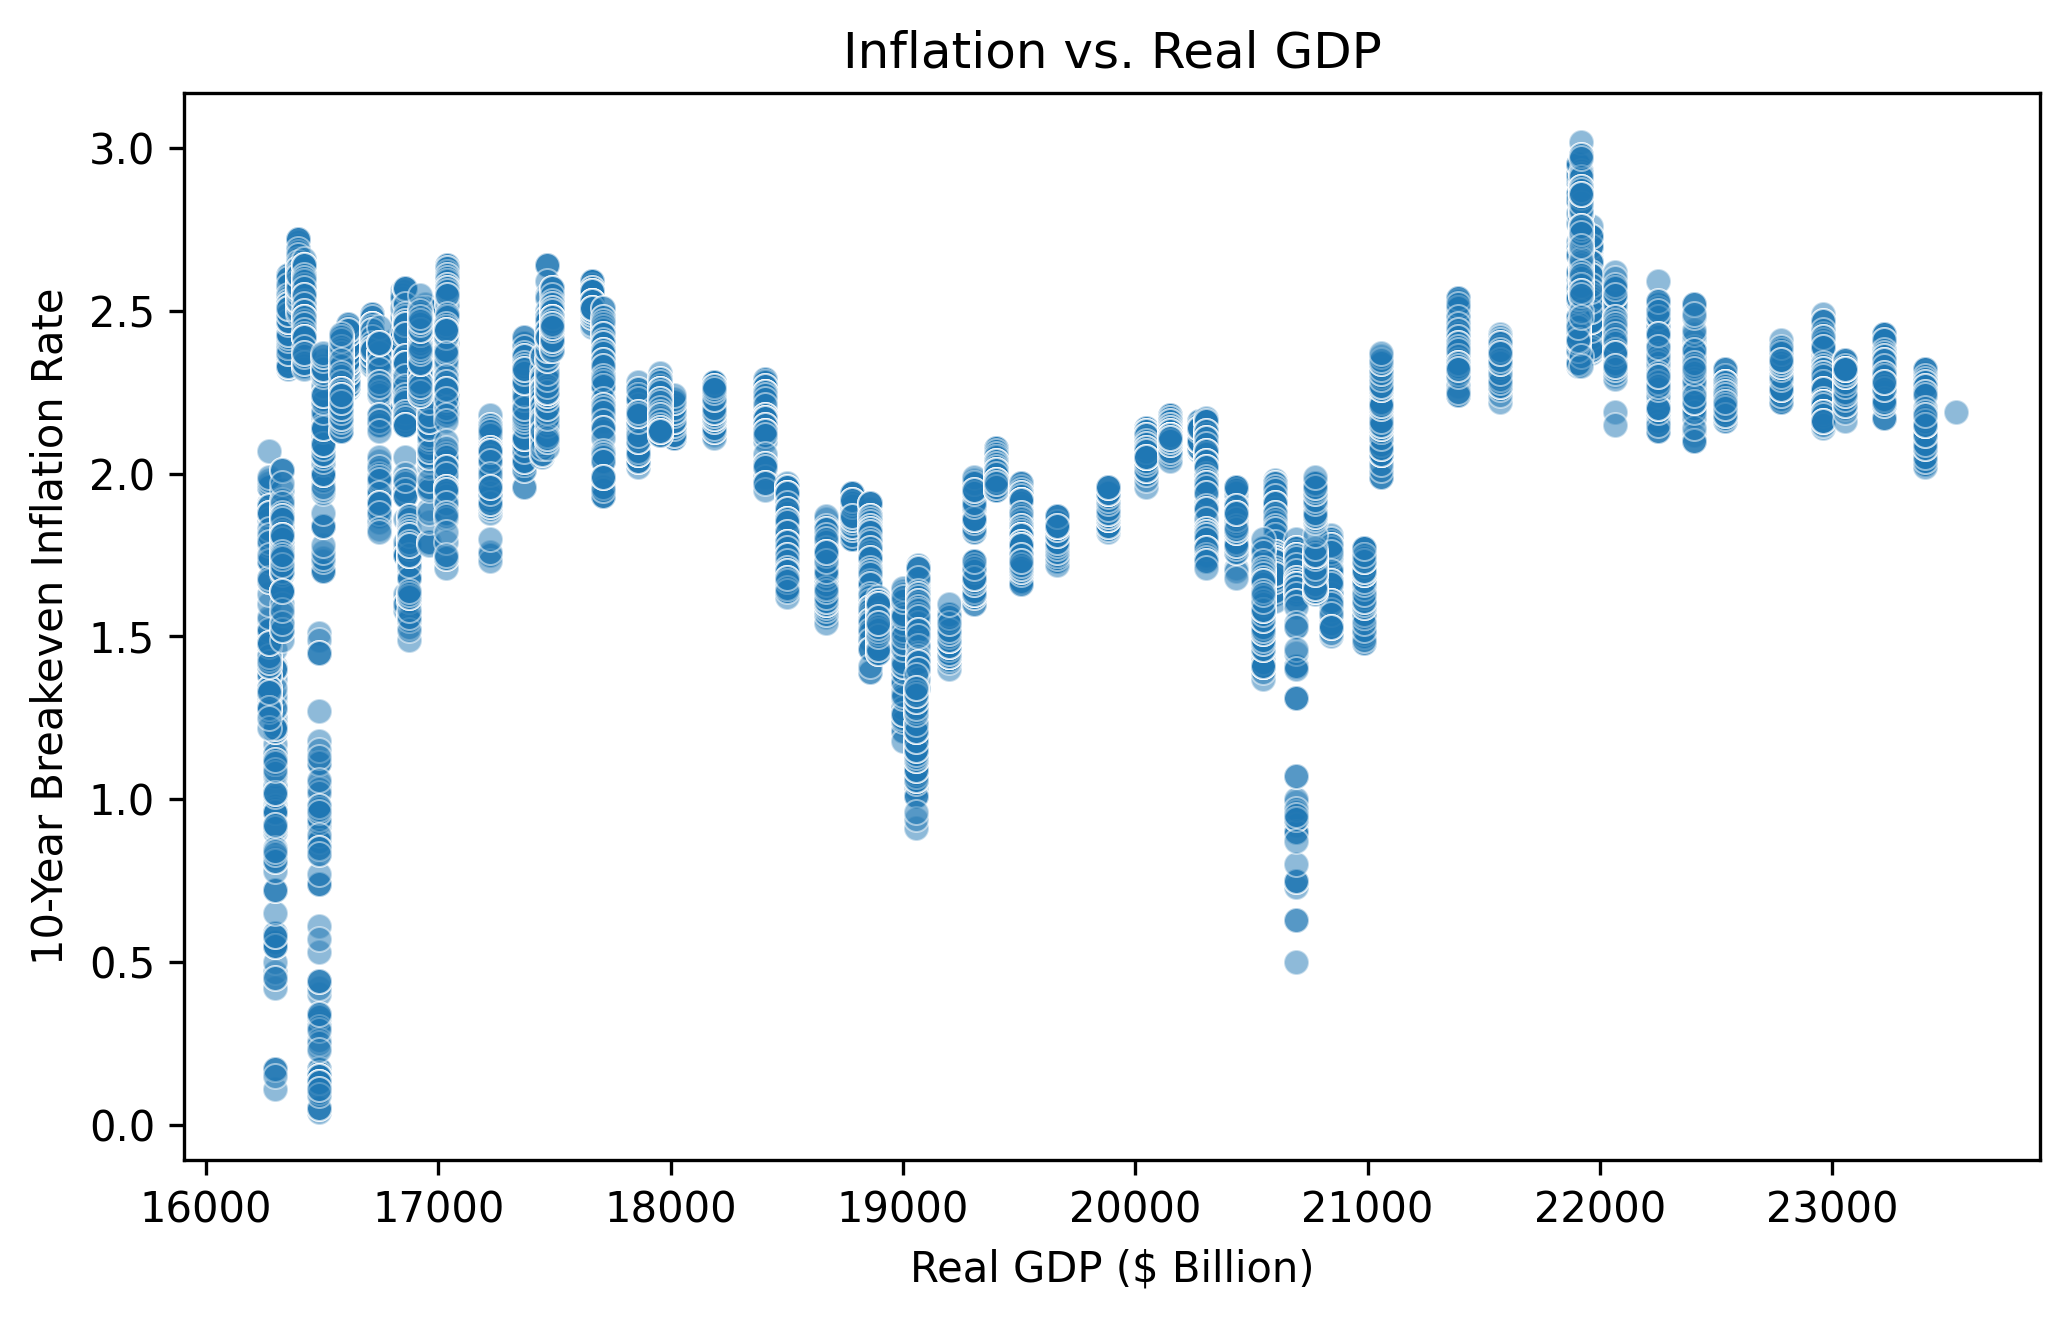

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4.5), dpi=300)
sns.scatterplot(x=df["GDPC1"], y=df["T10YIE"], alpha=0.5)
plt.title("Inflation vs. Real GDP")
plt.xlabel("Real GDP ($ Billion)")
plt.ylabel("10-Year Breakeven Inflation Rate")
plt.tight_layout()
plt.show()

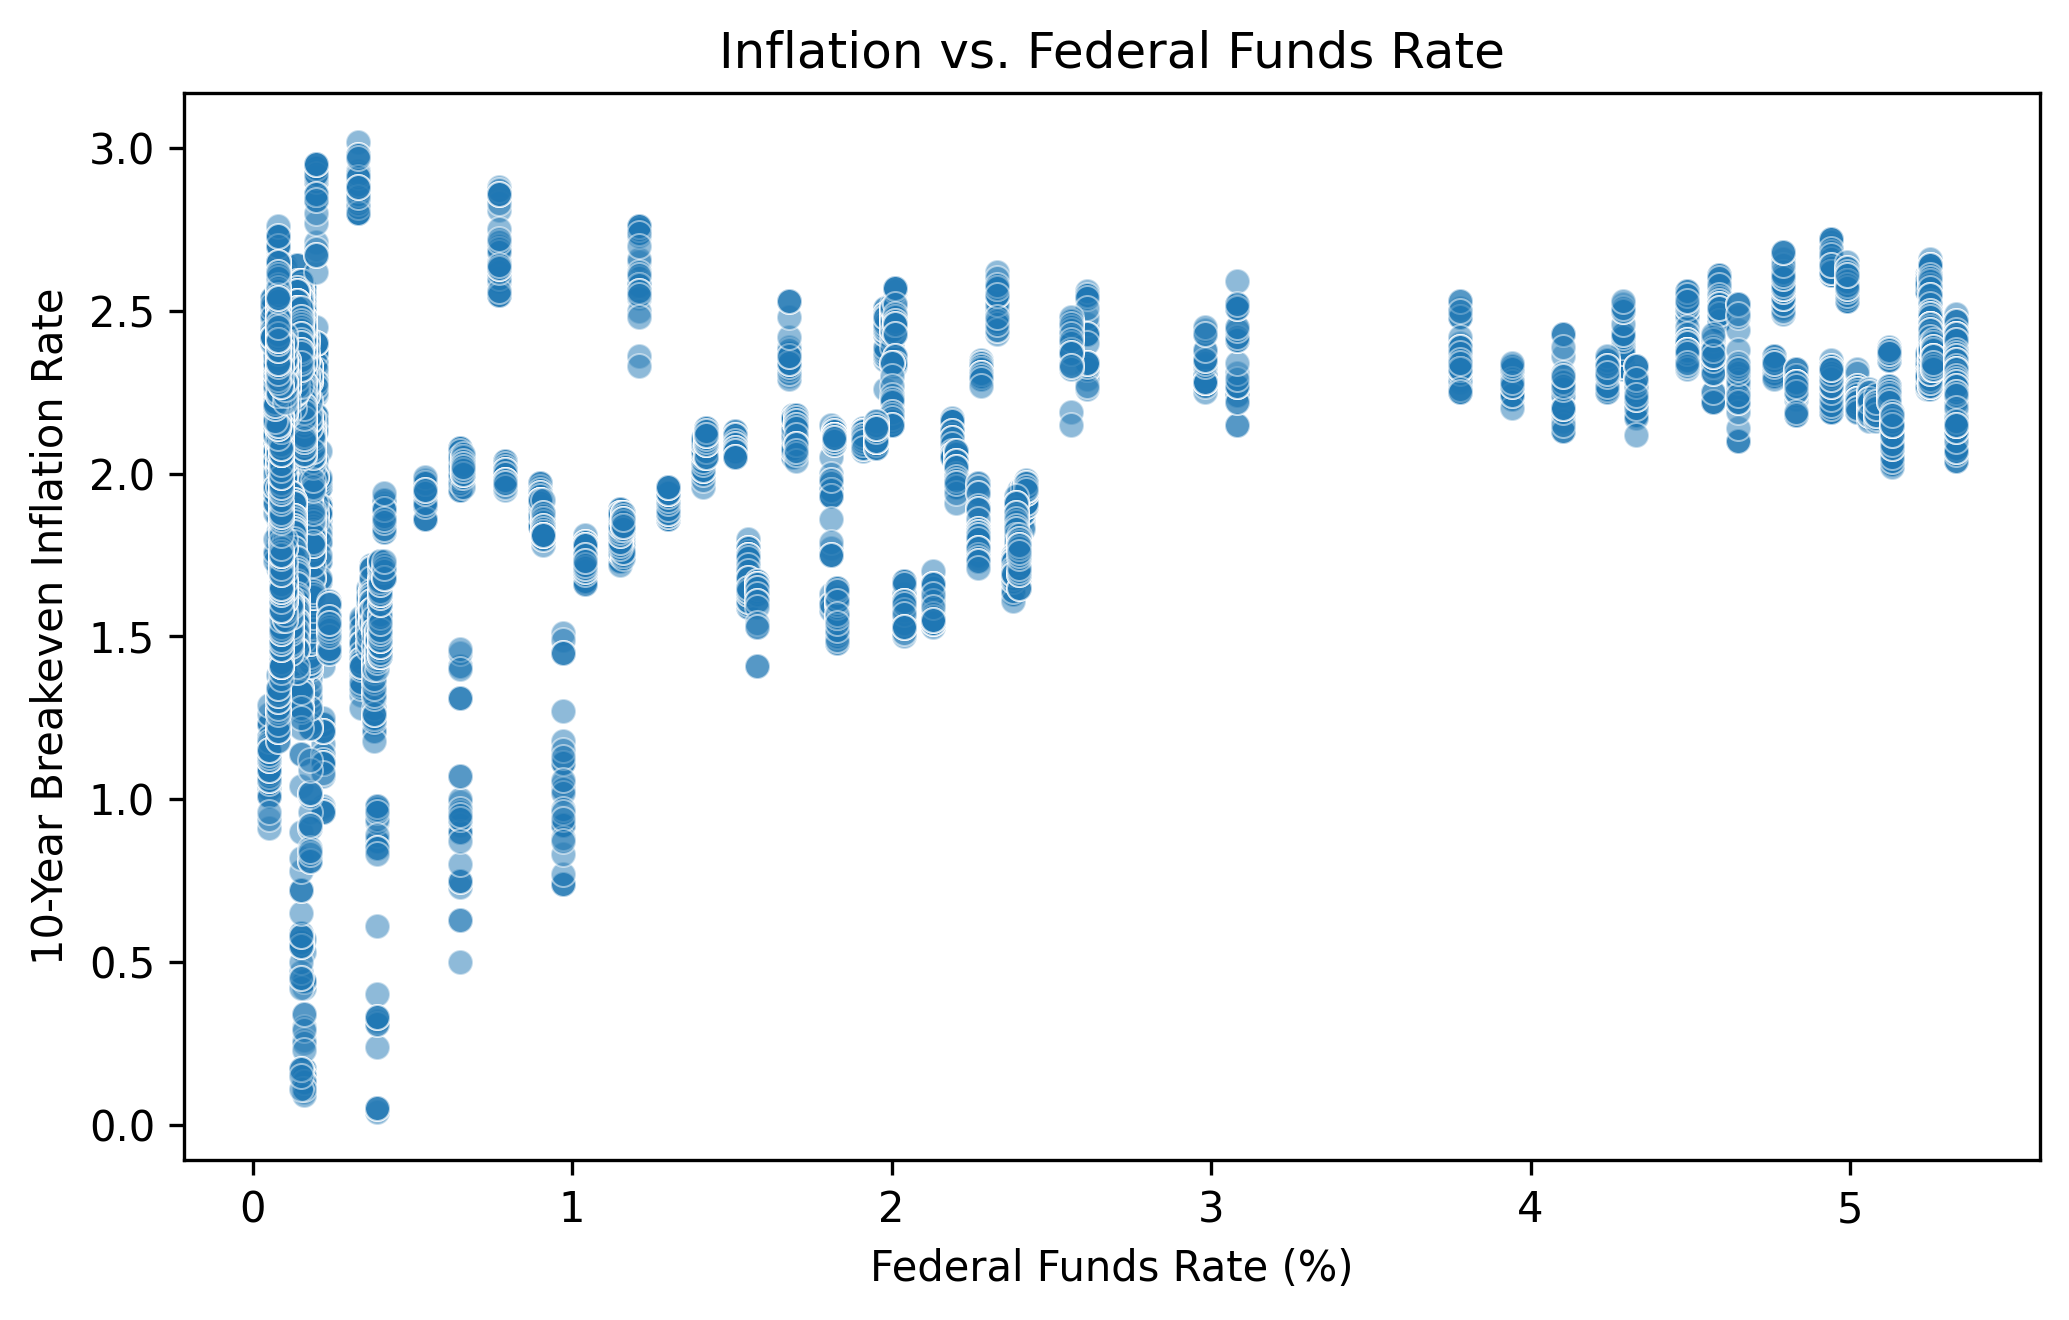

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4.5), dpi=300)
sns.scatterplot(x=df["FEDFUNDS"], y=df["T10YIE"], alpha=0.5)
plt.title("Inflation vs. Federal Funds Rate")
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("10-Year Breakeven Inflation Rate")
plt.tight_layout()
plt.show()

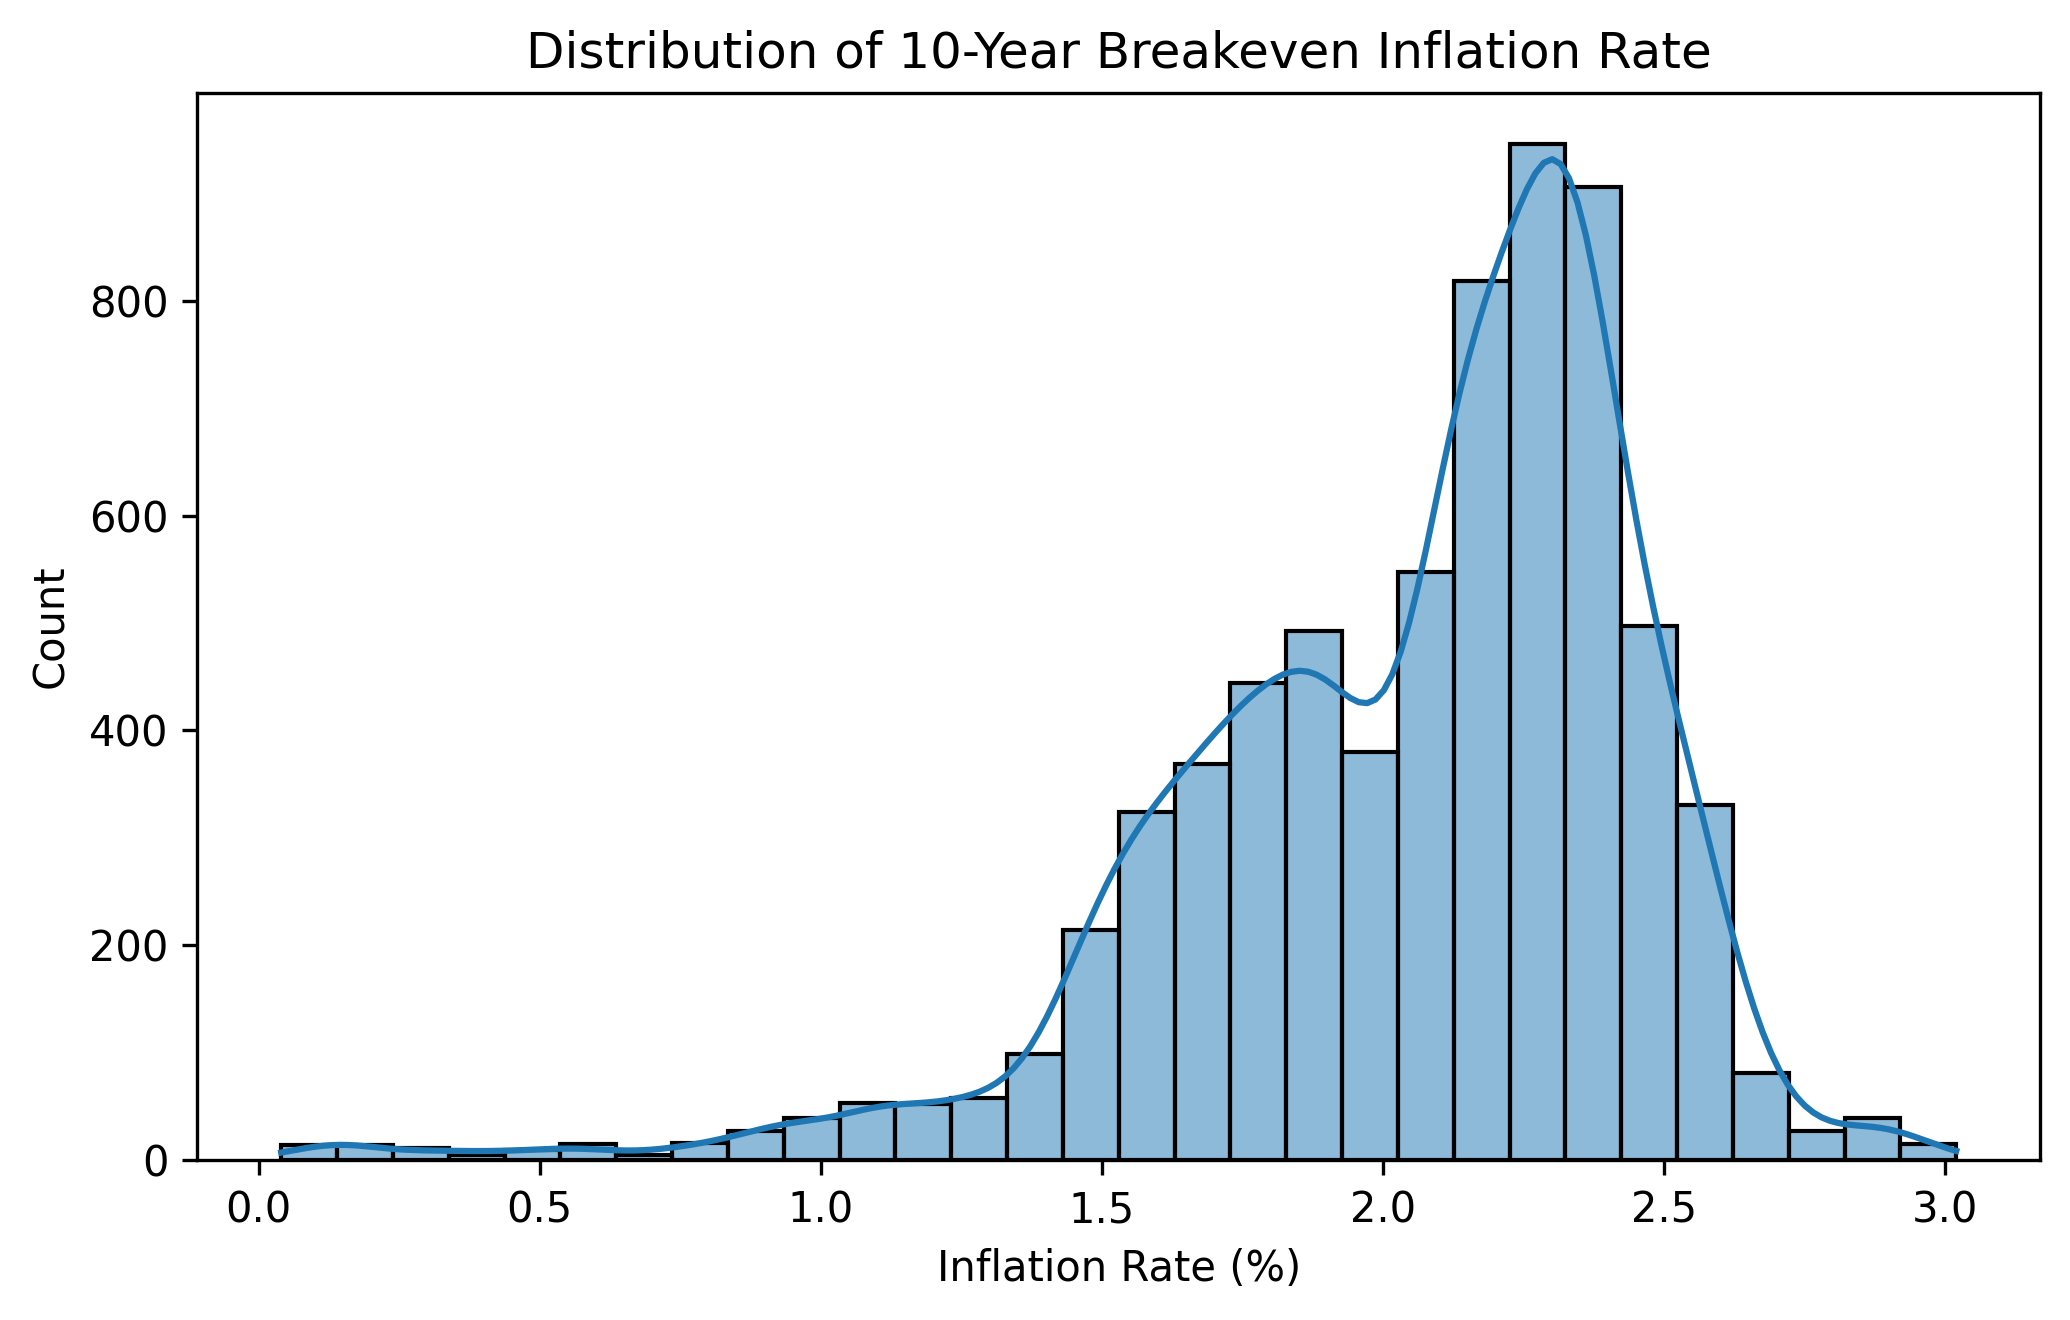

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4.5), dpi=300)
sns.histplot(df["T10YIE"], bins=30, kde=True)
plt.title("Distribution of 10-Year Breakeven Inflation Rate")
plt.xlabel("Inflation Rate (%)")
plt.tight_layout()
plt.show()

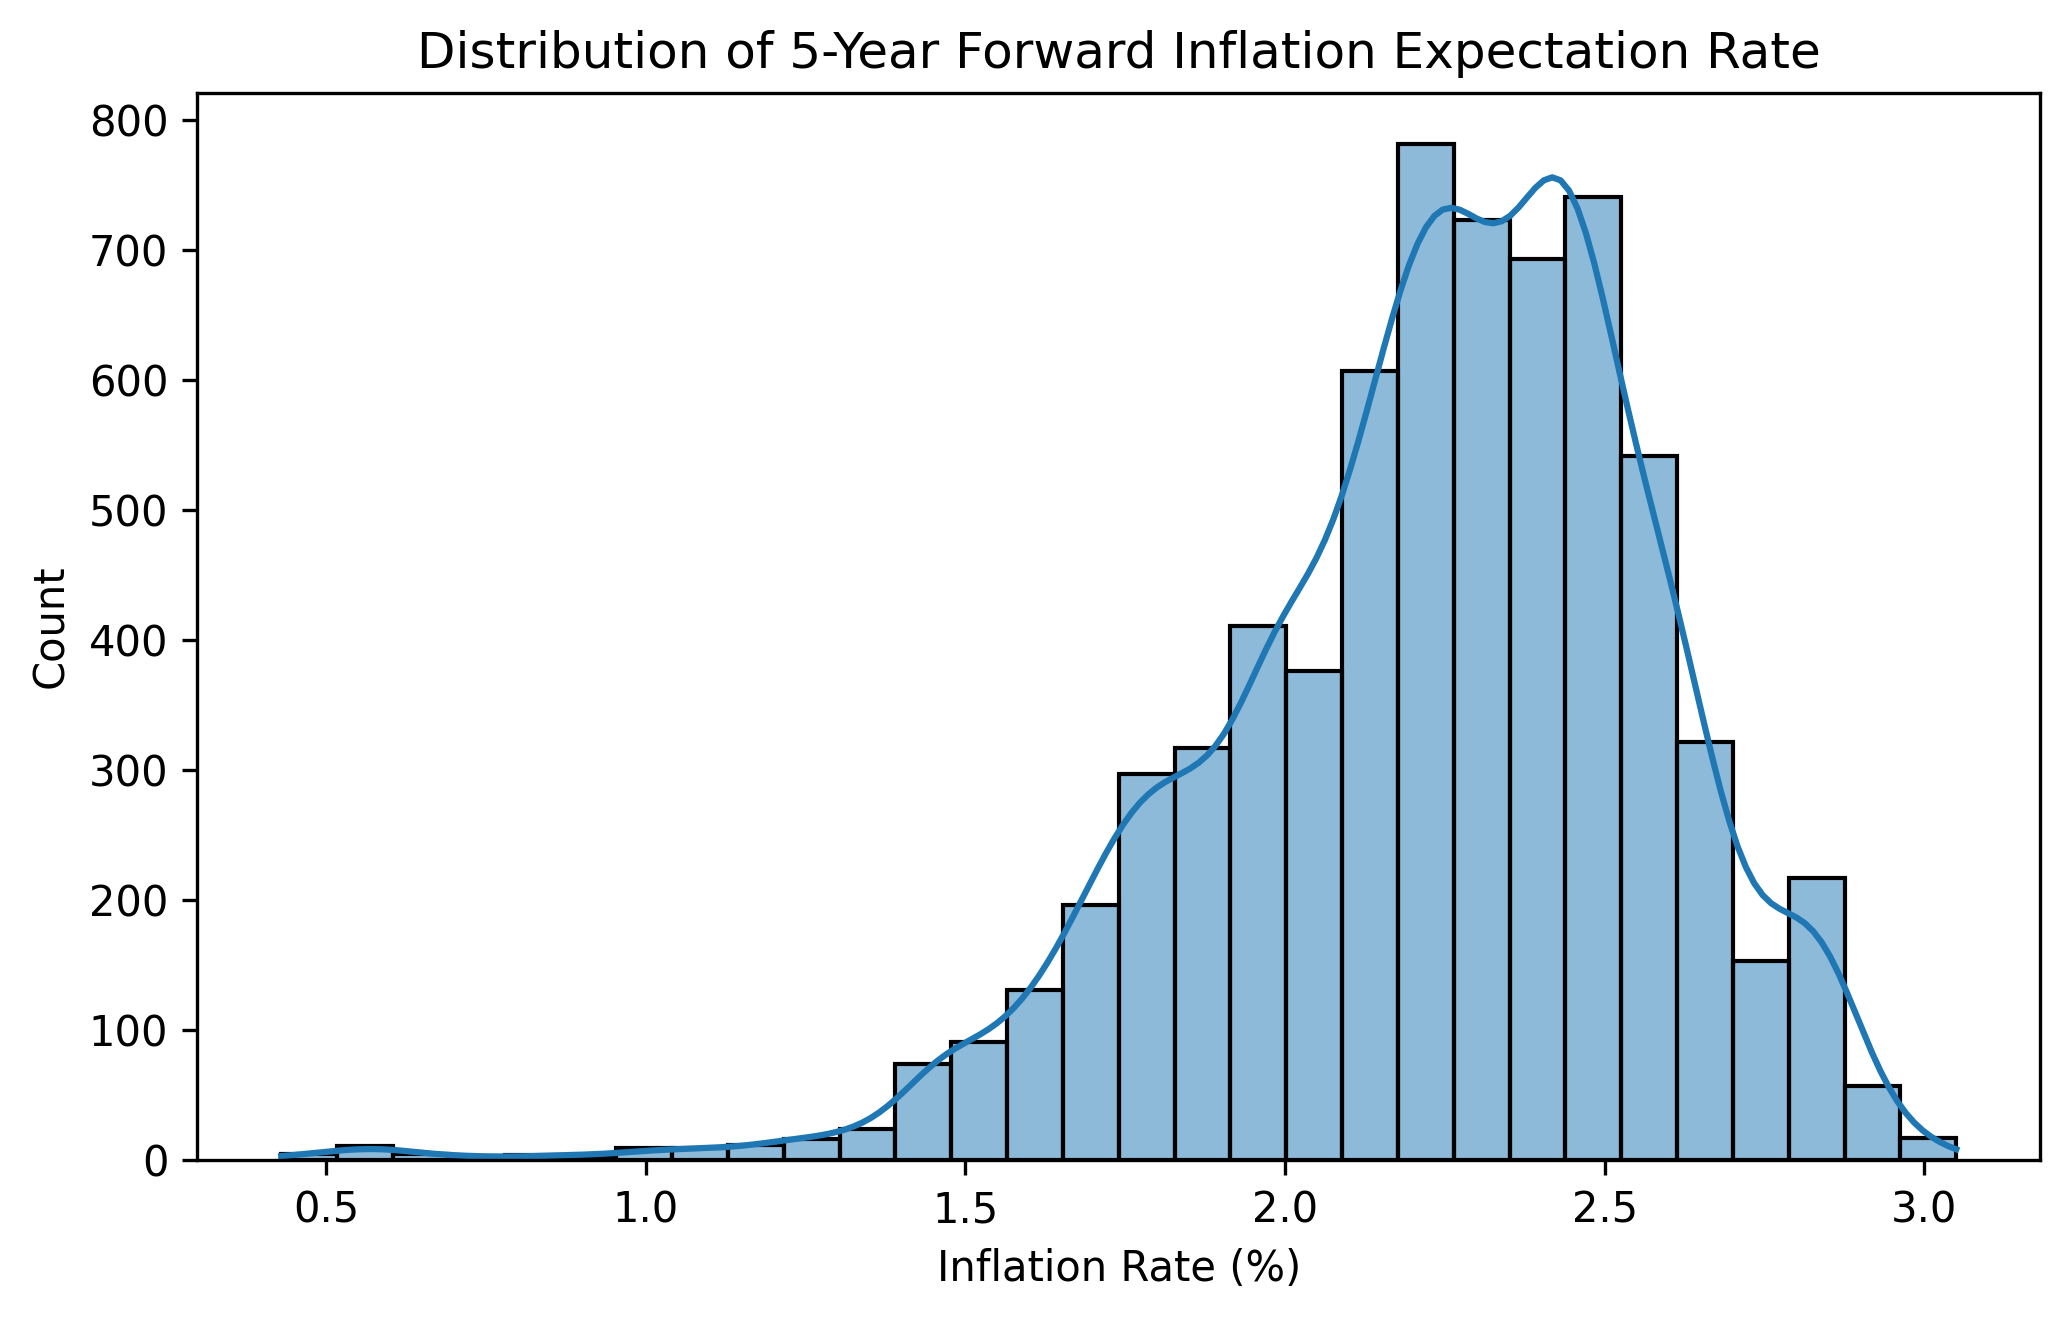

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4.5), dpi=300)
sns.histplot(df["T5YIFR"], bins=30, kde=True)
plt.title("Distribution of 5-Year Forward Inflation Expectation Rate")
plt.xlabel("Inflation Rate (%)")
plt.tight_layout()
plt.show()

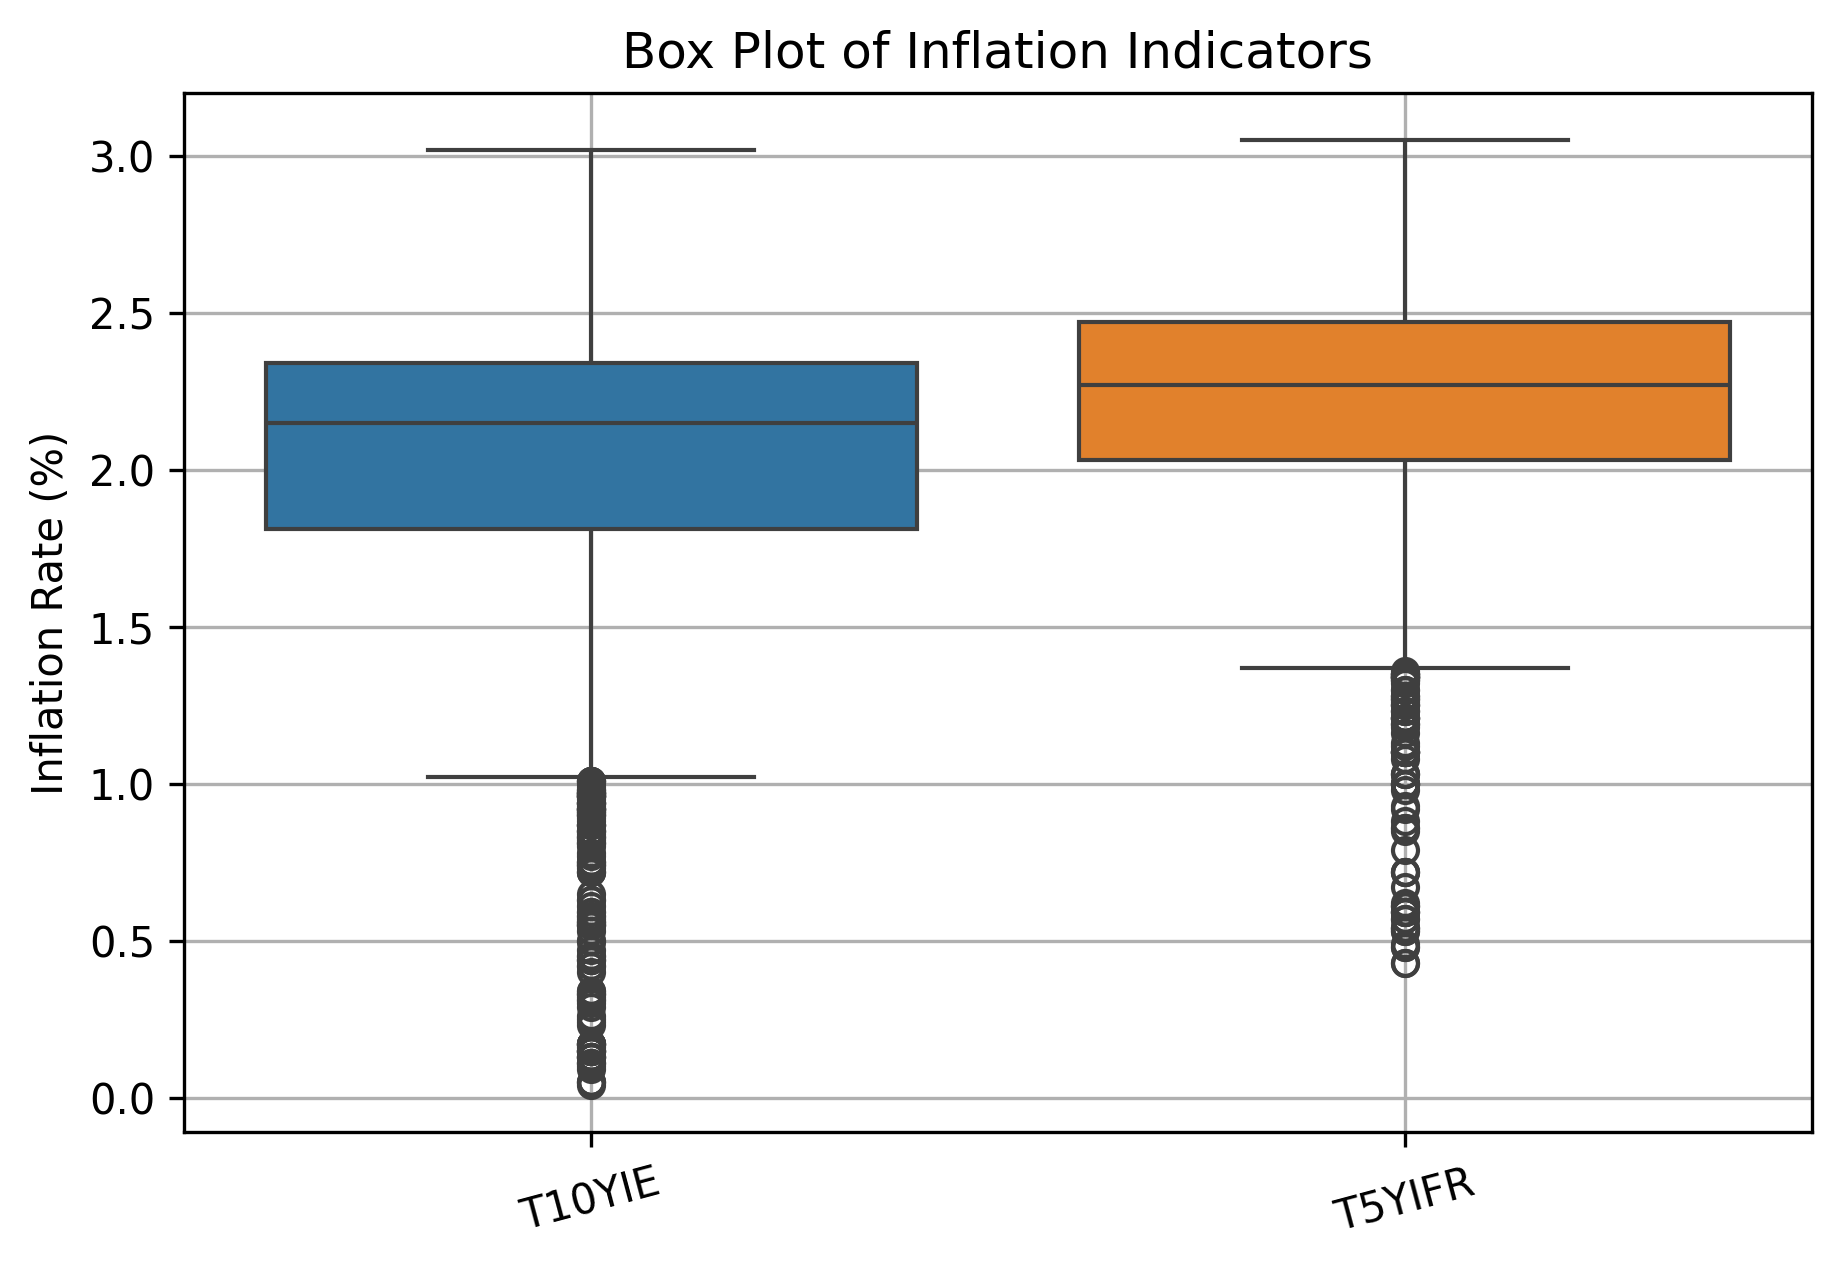

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4.5), dpi=300)
sns.boxplot(data=df[["T10YIE", "T5YIFR"]])
plt.title("Box Plot of Inflation Indicators")
plt.ylabel("Inflation Rate (%)")
plt.xticks(rotation=15)
plt.grid(True)
plt.show()

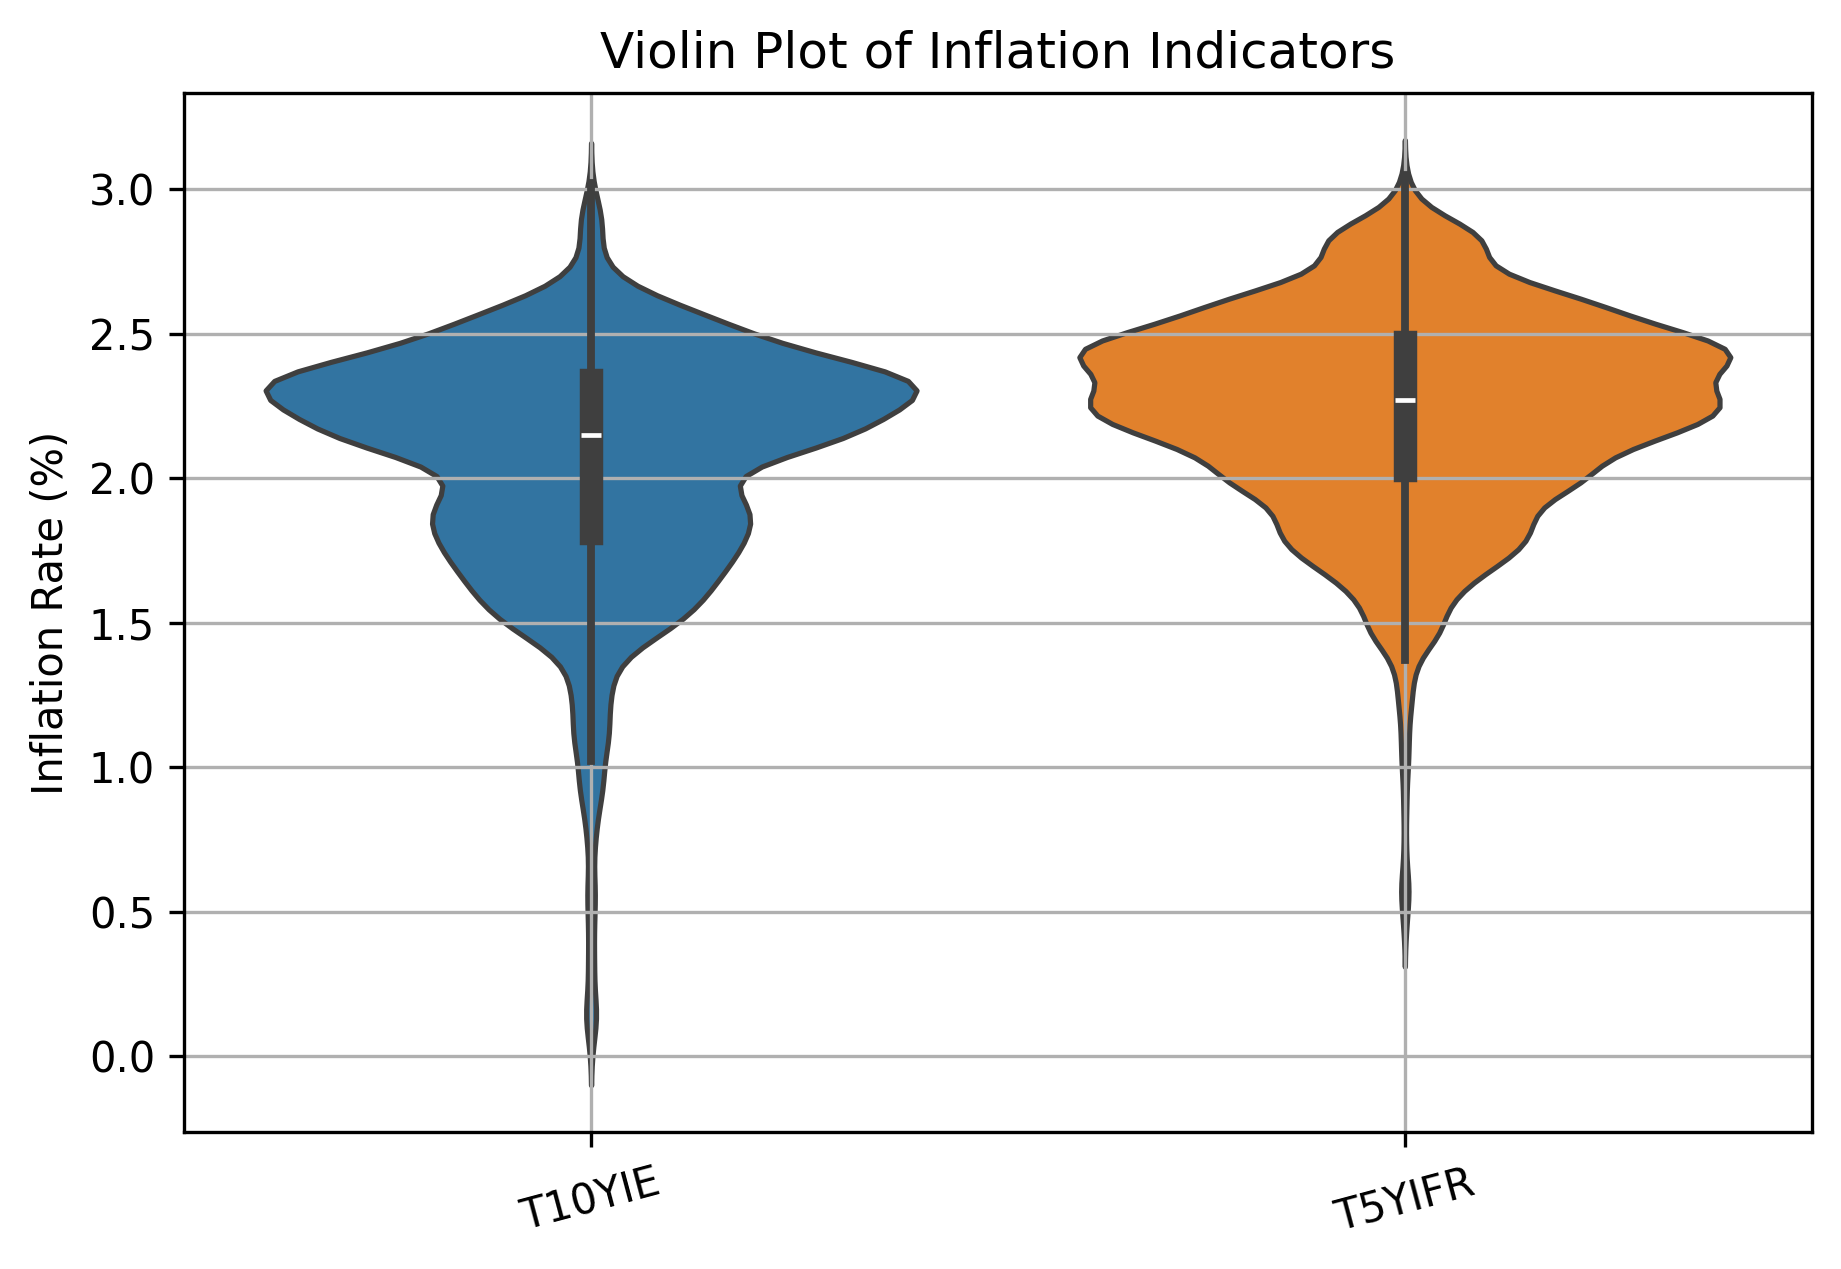

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4.5), dpi=300)
sns.violinplot(data=df[["T10YIE", "T5YIFR"]])
plt.title("Violin Plot of Inflation Indicators")
plt.ylabel("Inflation Rate (%)")
plt.xticks(rotation=15)
plt.grid(True)
plt.show()

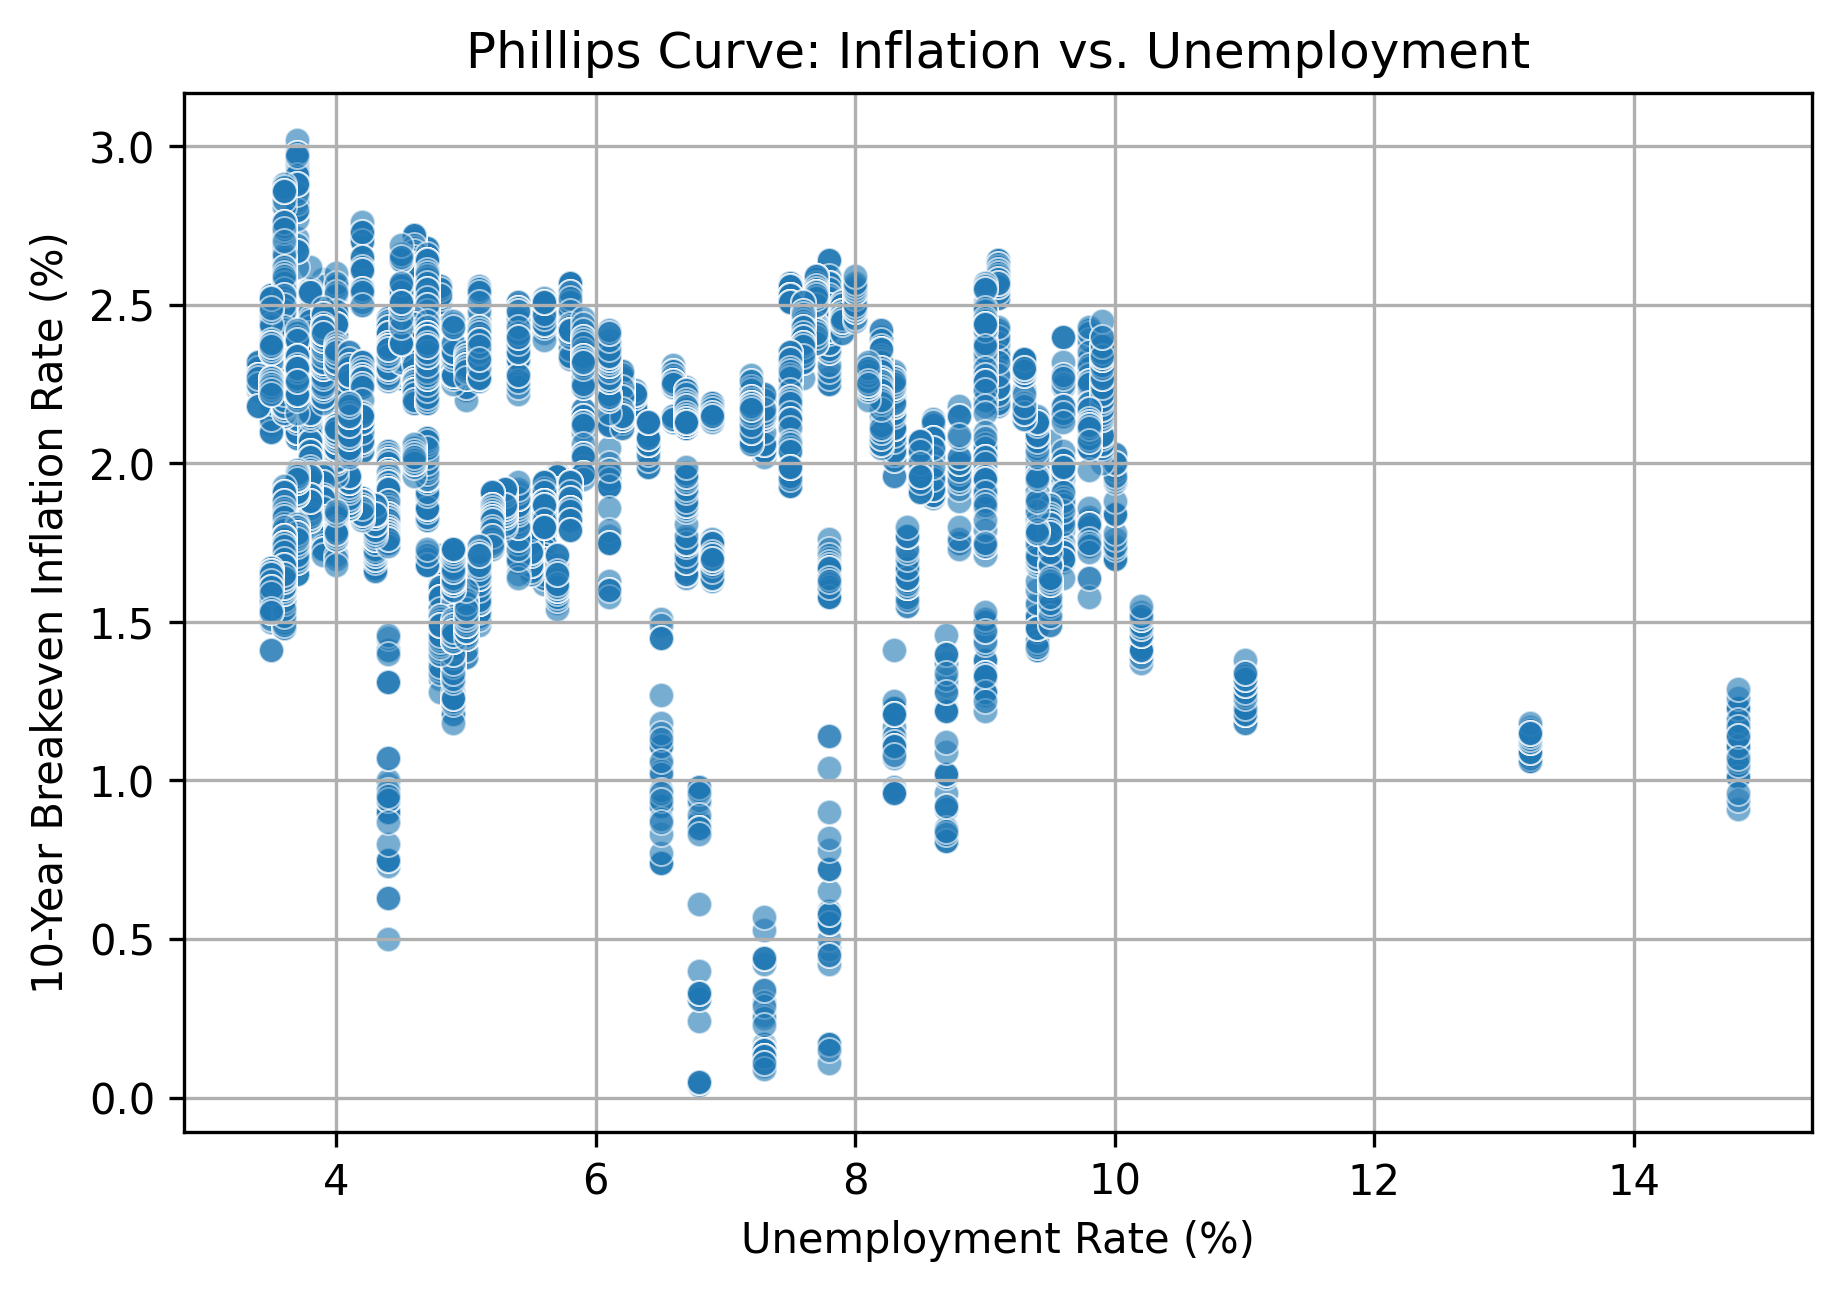

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot for Phillips Curve (Inflation vs. Unemployment)
plt.figure(figsize=(7, 4.5), dpi=300)
sns.scatterplot(x=df["UNRATE"], y=df["T10YIE"], alpha=0.6)
plt.title("Phillips Curve: Inflation vs. Unemployment")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("10-Year Breakeven Inflation Rate (%)")
plt.grid(True)
plt.show()


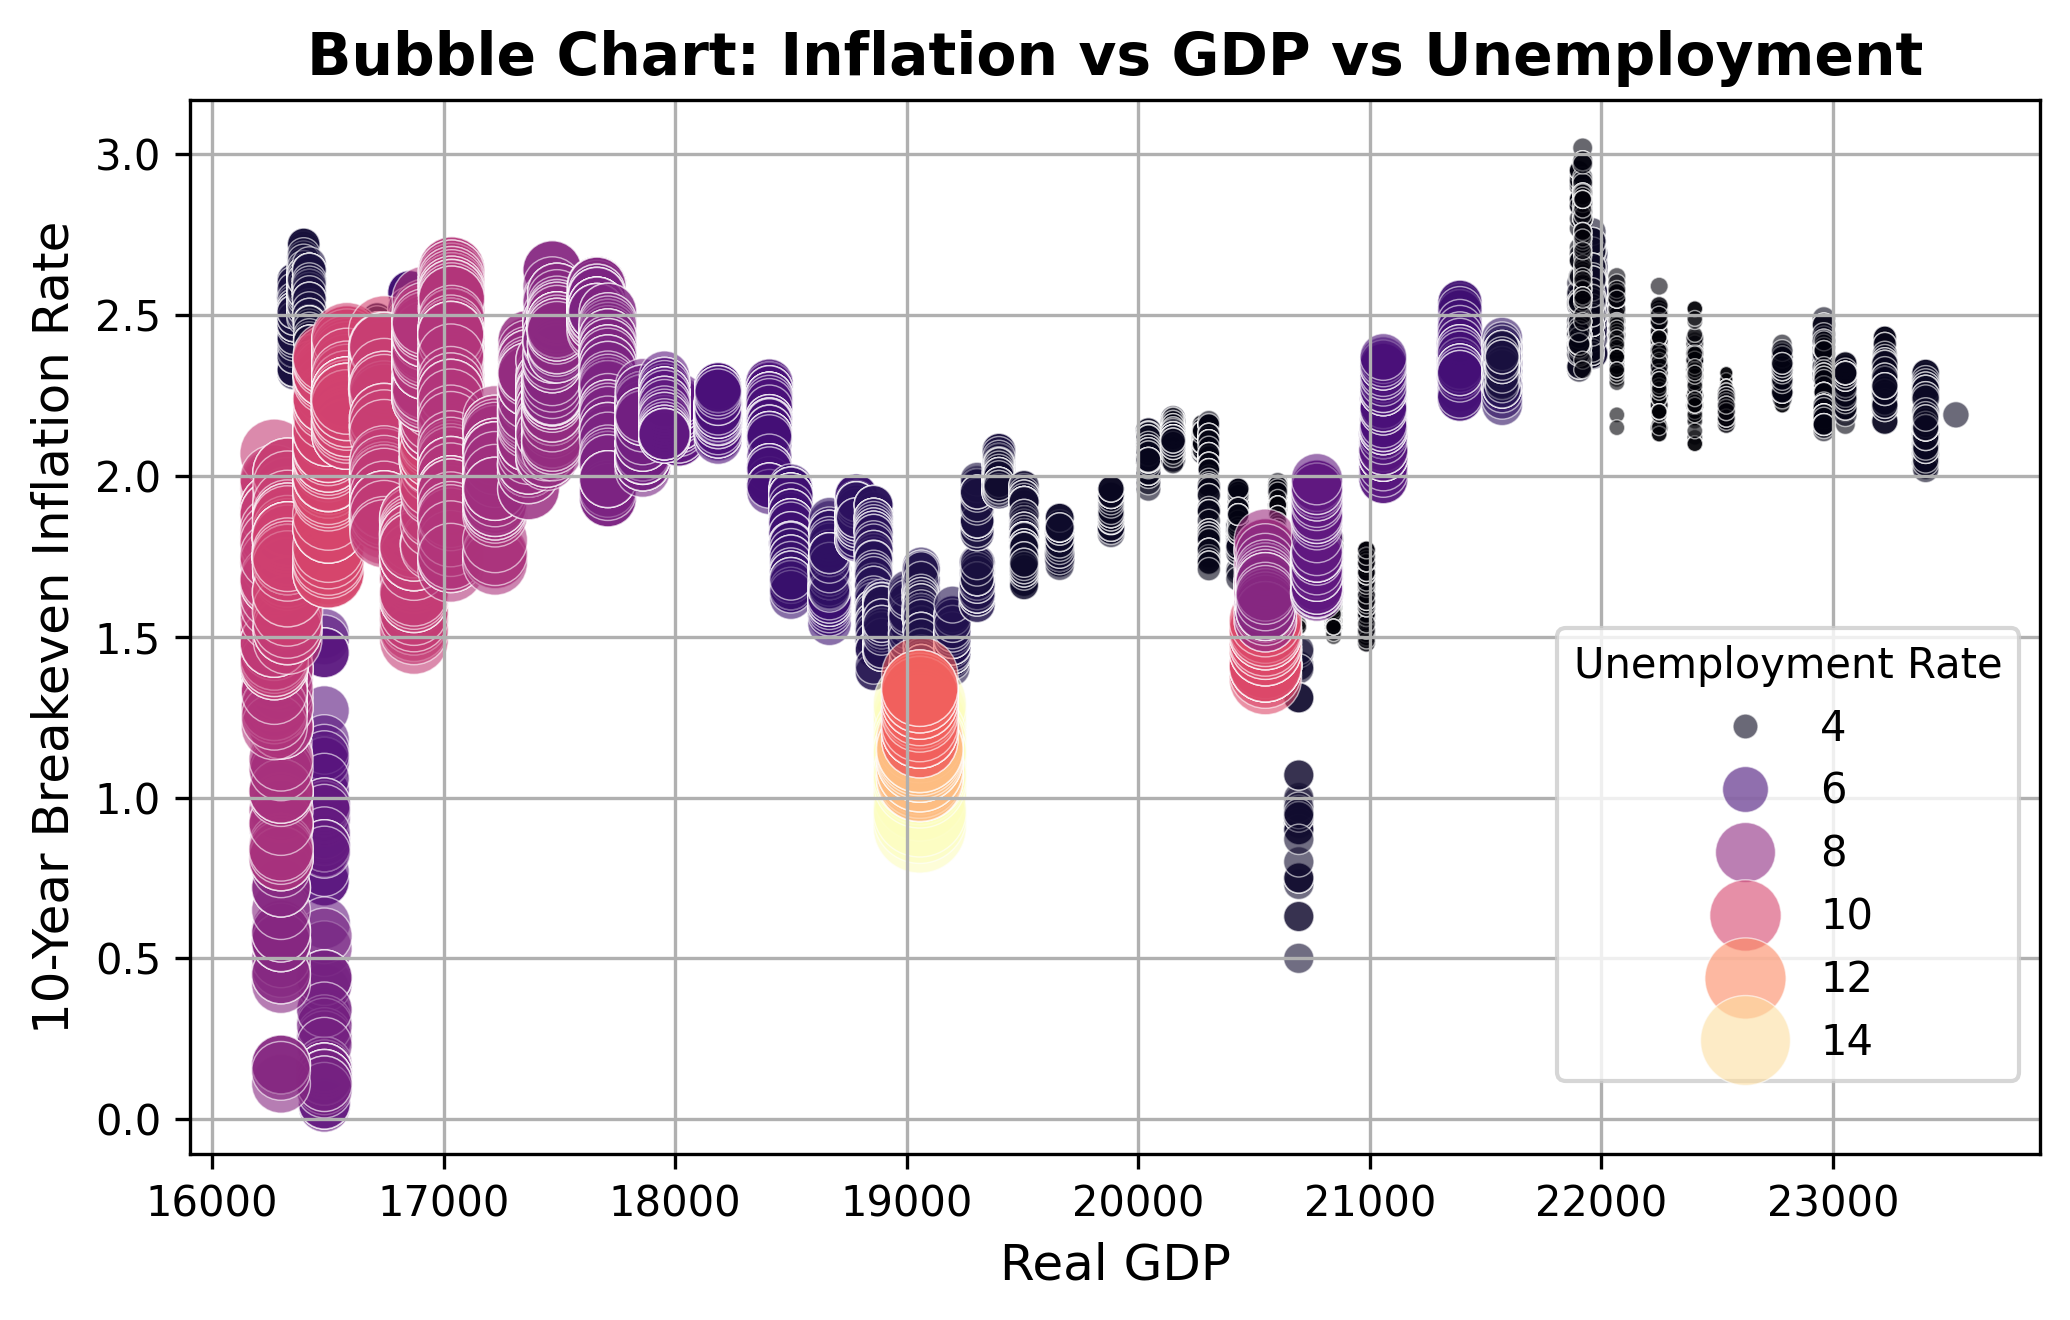

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bubble Chart: Inflation vs GDP vs Unemployment
plt.figure(figsize=(7, 4.5), dpi=300)
bubble_chart = sns.scatterplot(
    x=df["GDPC1"],
    y=df["T10YIE"],
    size=df["UNRATE"],
    hue=df["UNRATE"],
    alpha=0.6, sizes=(10, 500), palette="magma"
)

# Adjust titles and labels
plt.title("Bubble Chart: Inflation vs GDP vs Unemployment", fontsize=14, fontweight='bold')
plt.xlabel("Real GDP", fontsize=12)
plt.ylabel("10-Year Breakeven Inflation Rate", fontsize=12)
plt.grid(True)

# Move the legend to the lower right
plt.legend(title="Unemployment Rate", loc="lower right", bbox_to_anchor=(1, 0.05))

plt.tight_layout()
plt.show()

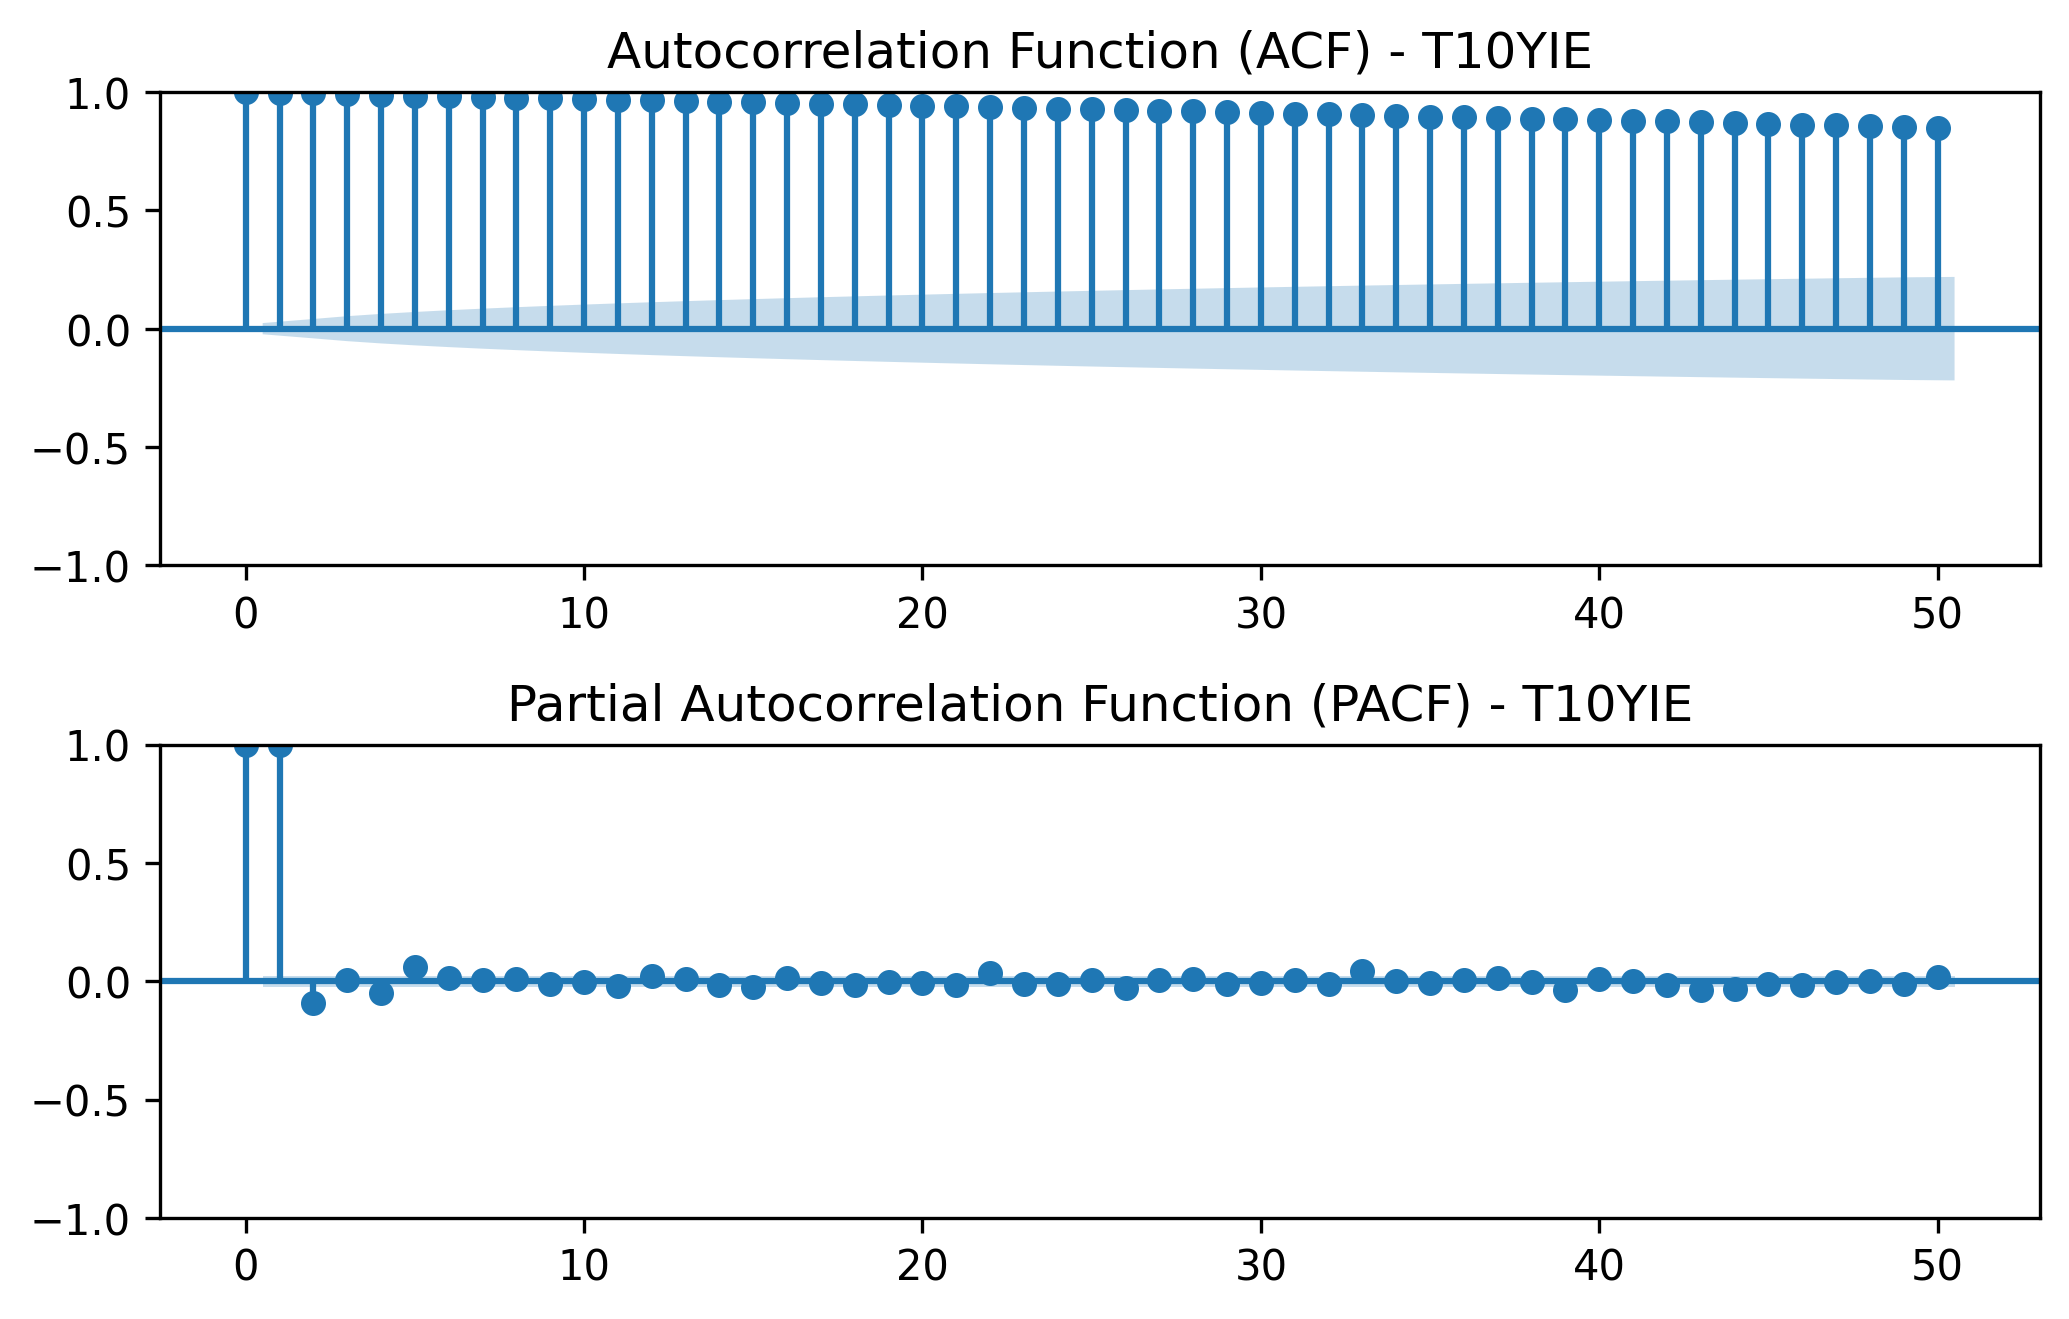

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF
fig, ax = plt.subplots(2, 1, figsize=(7, 4.5), dpi=300)

plot_acf(df["T10YIE"].dropna(), lags=50, ax=ax[0])
ax[0].set_title("Autocorrelation Function (ACF) - T10YIE")

plot_pacf(df["T10YIE"].dropna(), lags=50, ax=ax[1])
ax[1].set_title("Partial Autocorrelation Function (PACF) - T10YIE")

plt.tight_layout()
plt.show()

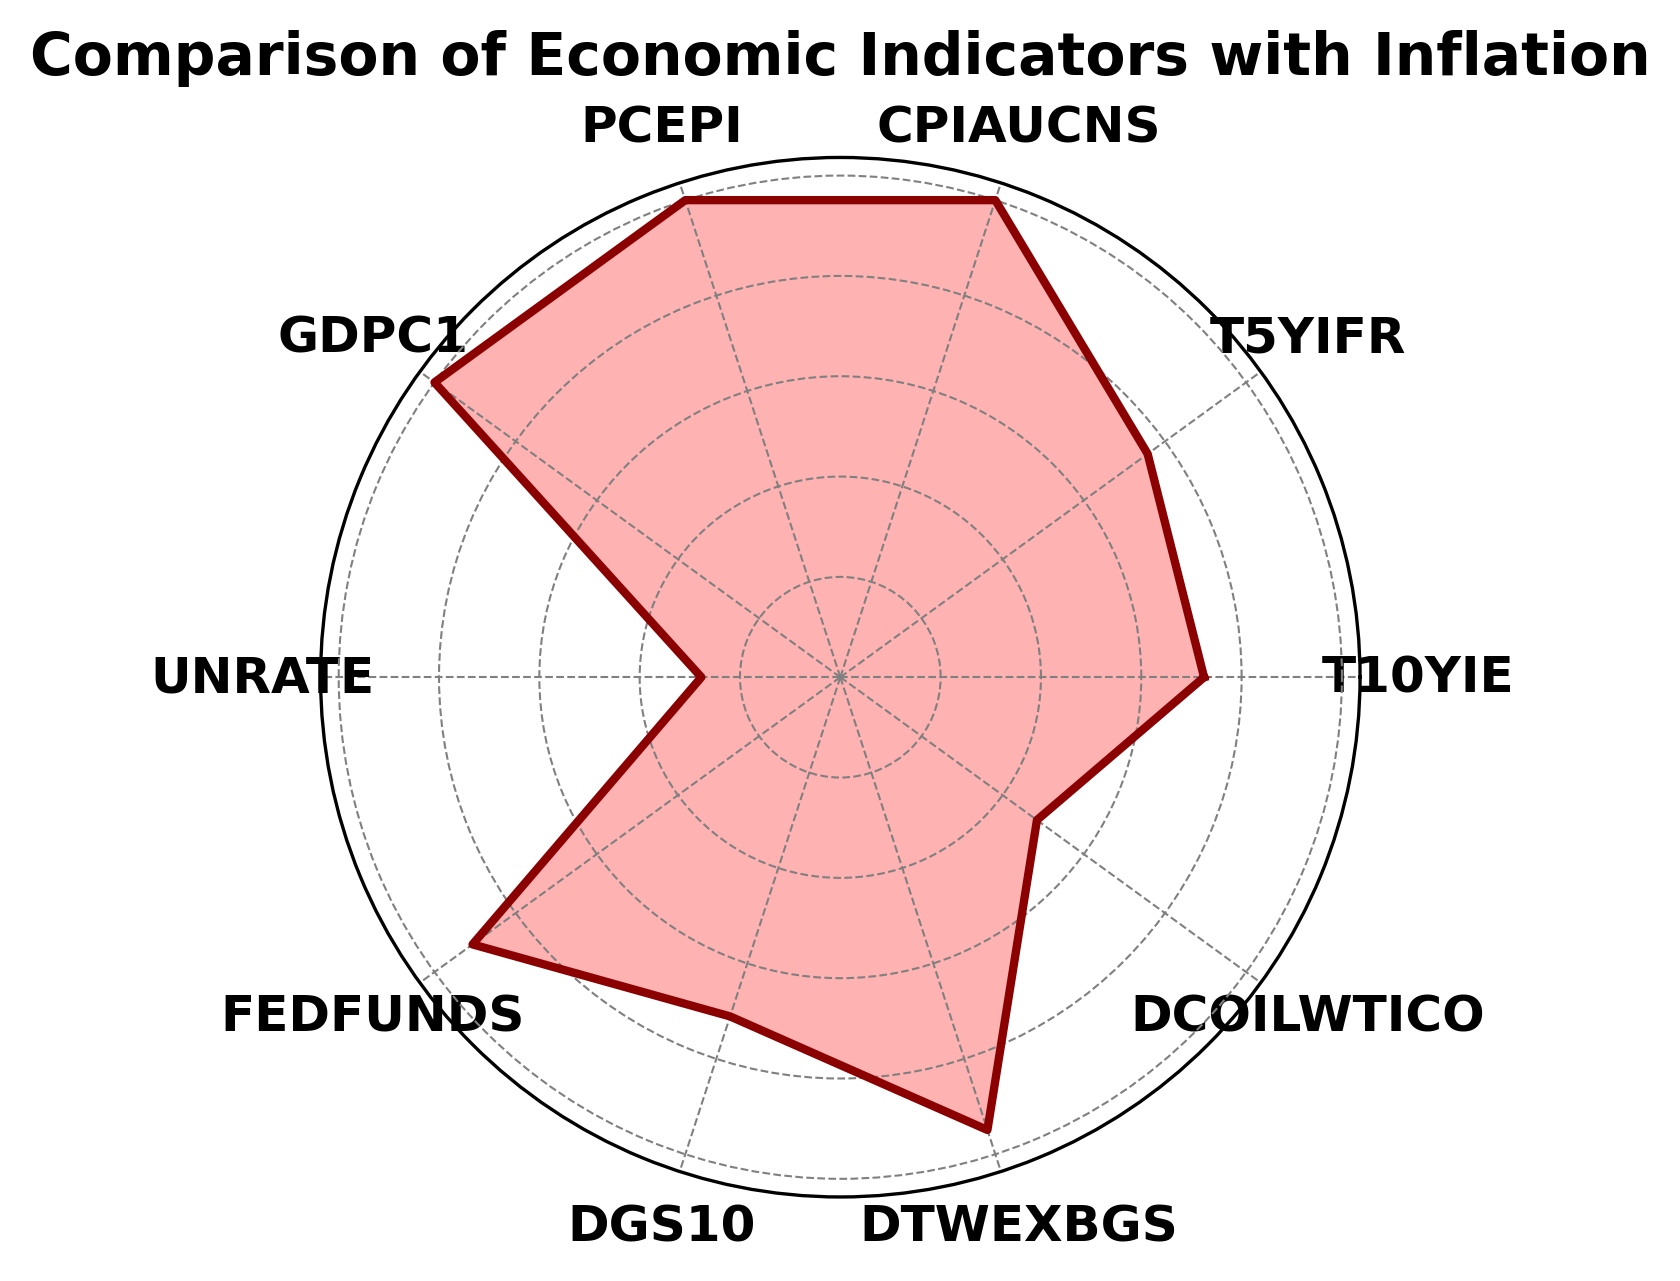

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Select key economic indicators
indicators = ['T10YIE', 'T5YIFR', 'CPIAUCNS', 'PCEPI', 'GDPC1', 'UNRATE', 'FEDFUNDS', 'DGS10', 'DTWEXBGS', 'DCOILWTICO']

# Extract the latest values
latest_values = df[indicators].iloc[-1].values

# Normalize values for better visualization
max_values = df[indicators].max().values
normalized_values = latest_values / max_values  # Normalize data

# Compute angles for each indicator
angles = np.linspace(0, 2 * np.pi, len(indicators), endpoint=False).tolist()
angles += angles[:1]  # Close the circle

# Close the data circle for plotting
normalized_values = np.concatenate((normalized_values, [normalized_values[0]]))

# Create Radar Chart using plt.figure and a polar subplot with the specified size and dpi
fig = plt.figure(figsize=(7, 4.5), dpi=300)
ax = fig.add_subplot(1, 1, 1, polar=True)

# Plot the filled area with better transparency (label removed)
ax.fill(angles, normalized_values, color="red", alpha=0.3)
ax.plot(angles, normalized_values, color="darkred", linewidth=2, linestyle='solid')

# Improve label positioning
ax.set_xticks(angles[:-1])
ax.set_xticklabels(indicators, fontsize=12, fontweight='bold', color="black", ha="center")

# Adjust radial labels for better readability
ax.set_yticklabels([])
ax.grid(color='gray', linestyle='dashed', linewidth=0.5)

# Title with better alignment
plt.title("Comparison of Economic Indicators with Inflation", fontsize=14, fontweight='bold', pad=20)

# Show the final improved radar chart without a legend
plt.show()


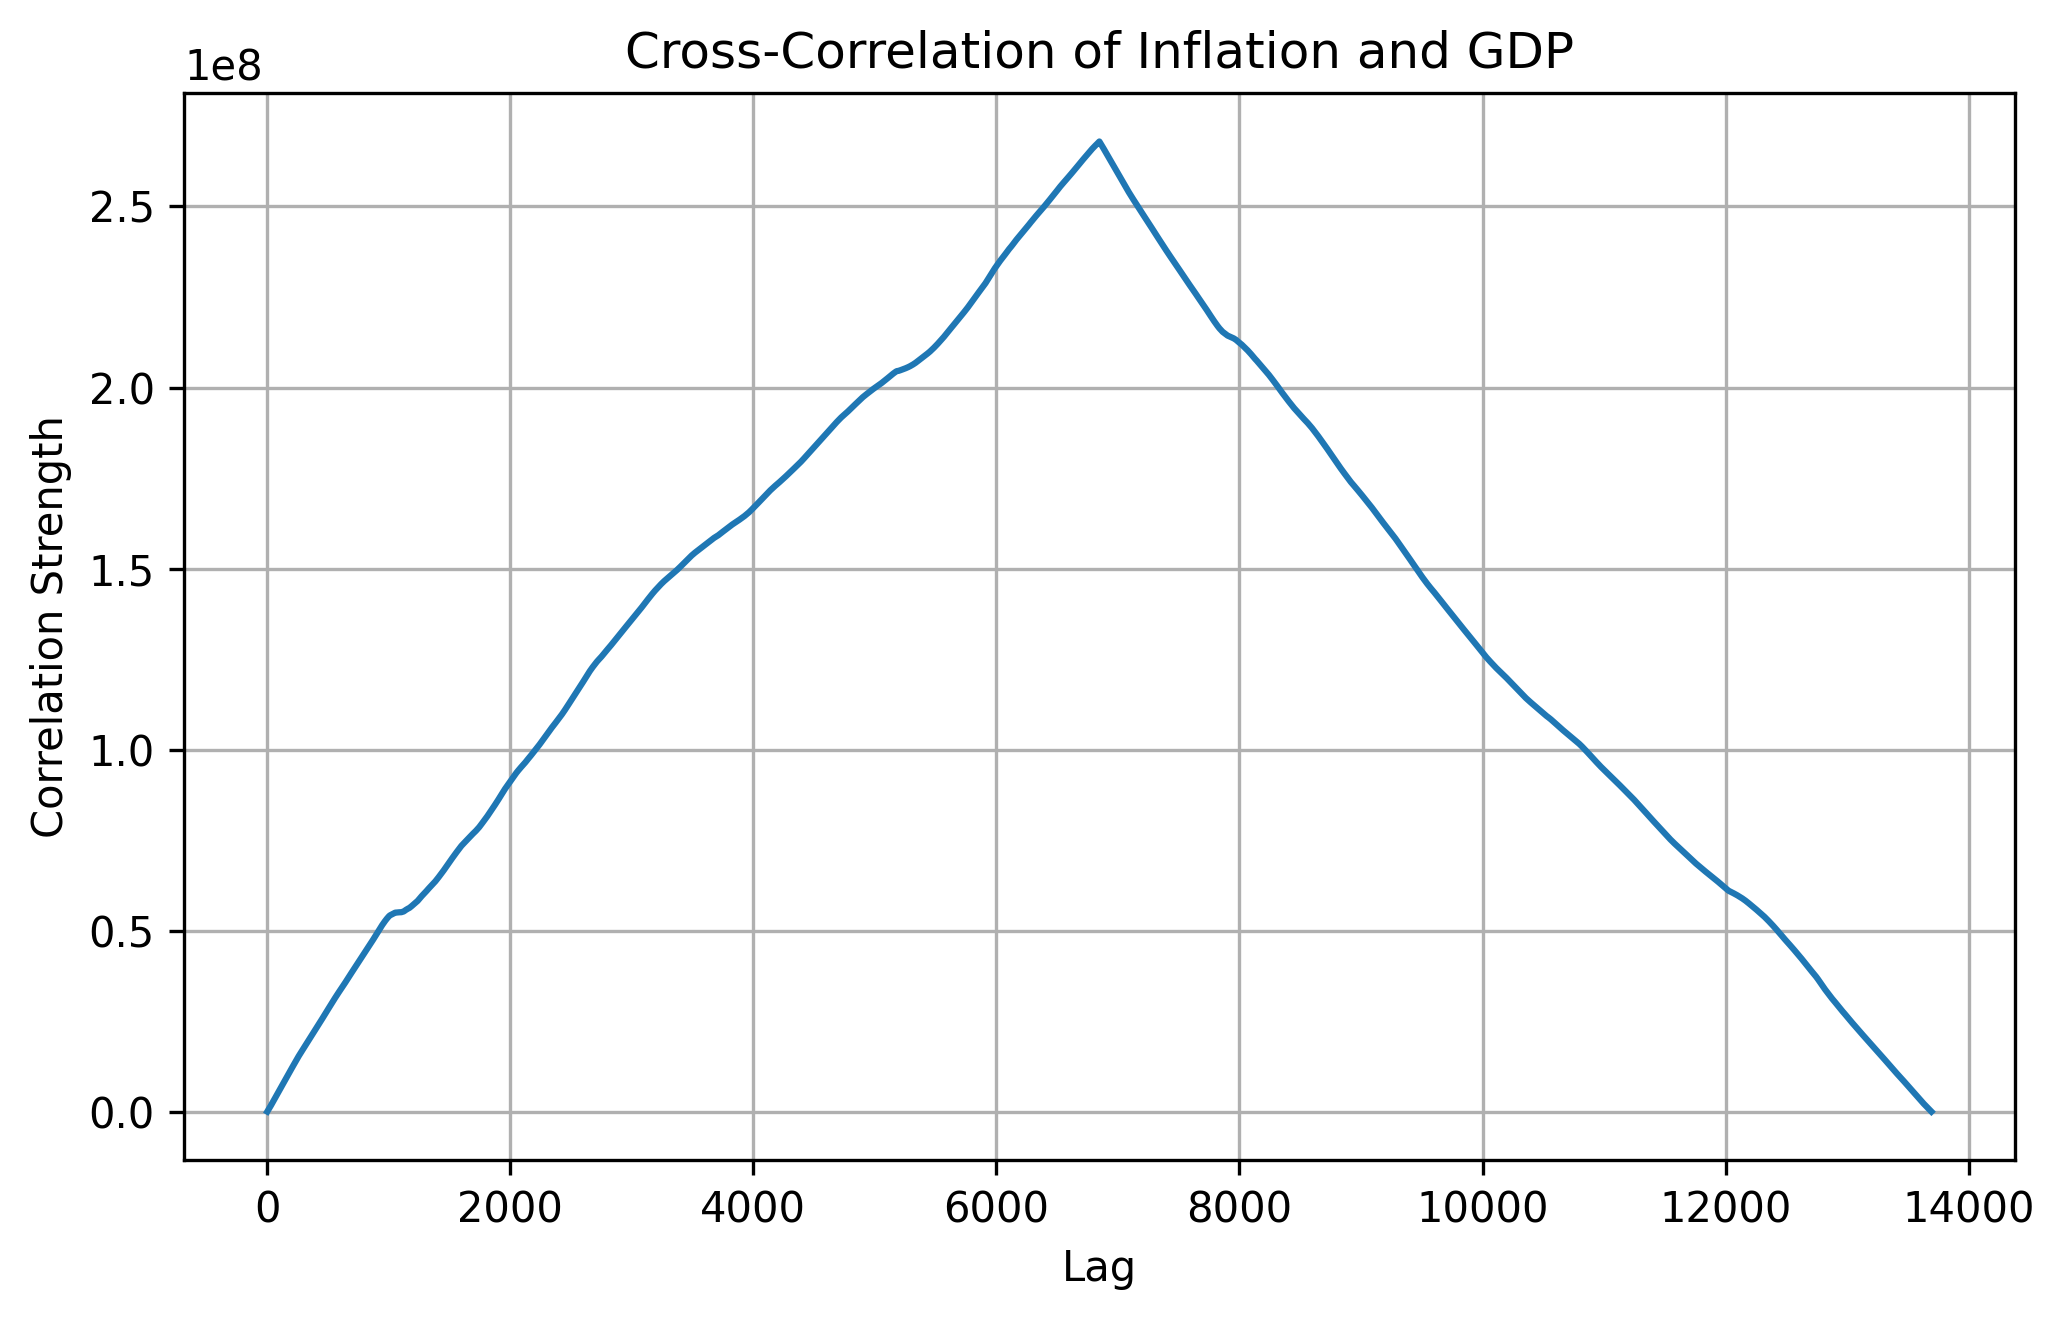

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

# Compute cross-correlation of inflation with GDP
correlation_lags = np.correlate(
    df["T10YIE"].dropna(),
    df["GDPC1"].dropna(), mode="full"
)

# Plot cross-correlation with the specified figure size and dpi
plt.figure(figsize=(7, 4.5), dpi=300)
plt.plot(correlation_lags)
plt.title("Cross-Correlation of Inflation and GDP")
plt.xlabel("Lag")
plt.ylabel("Correlation Strength")
plt.grid(True)
plt.tight_layout()
plt.show()

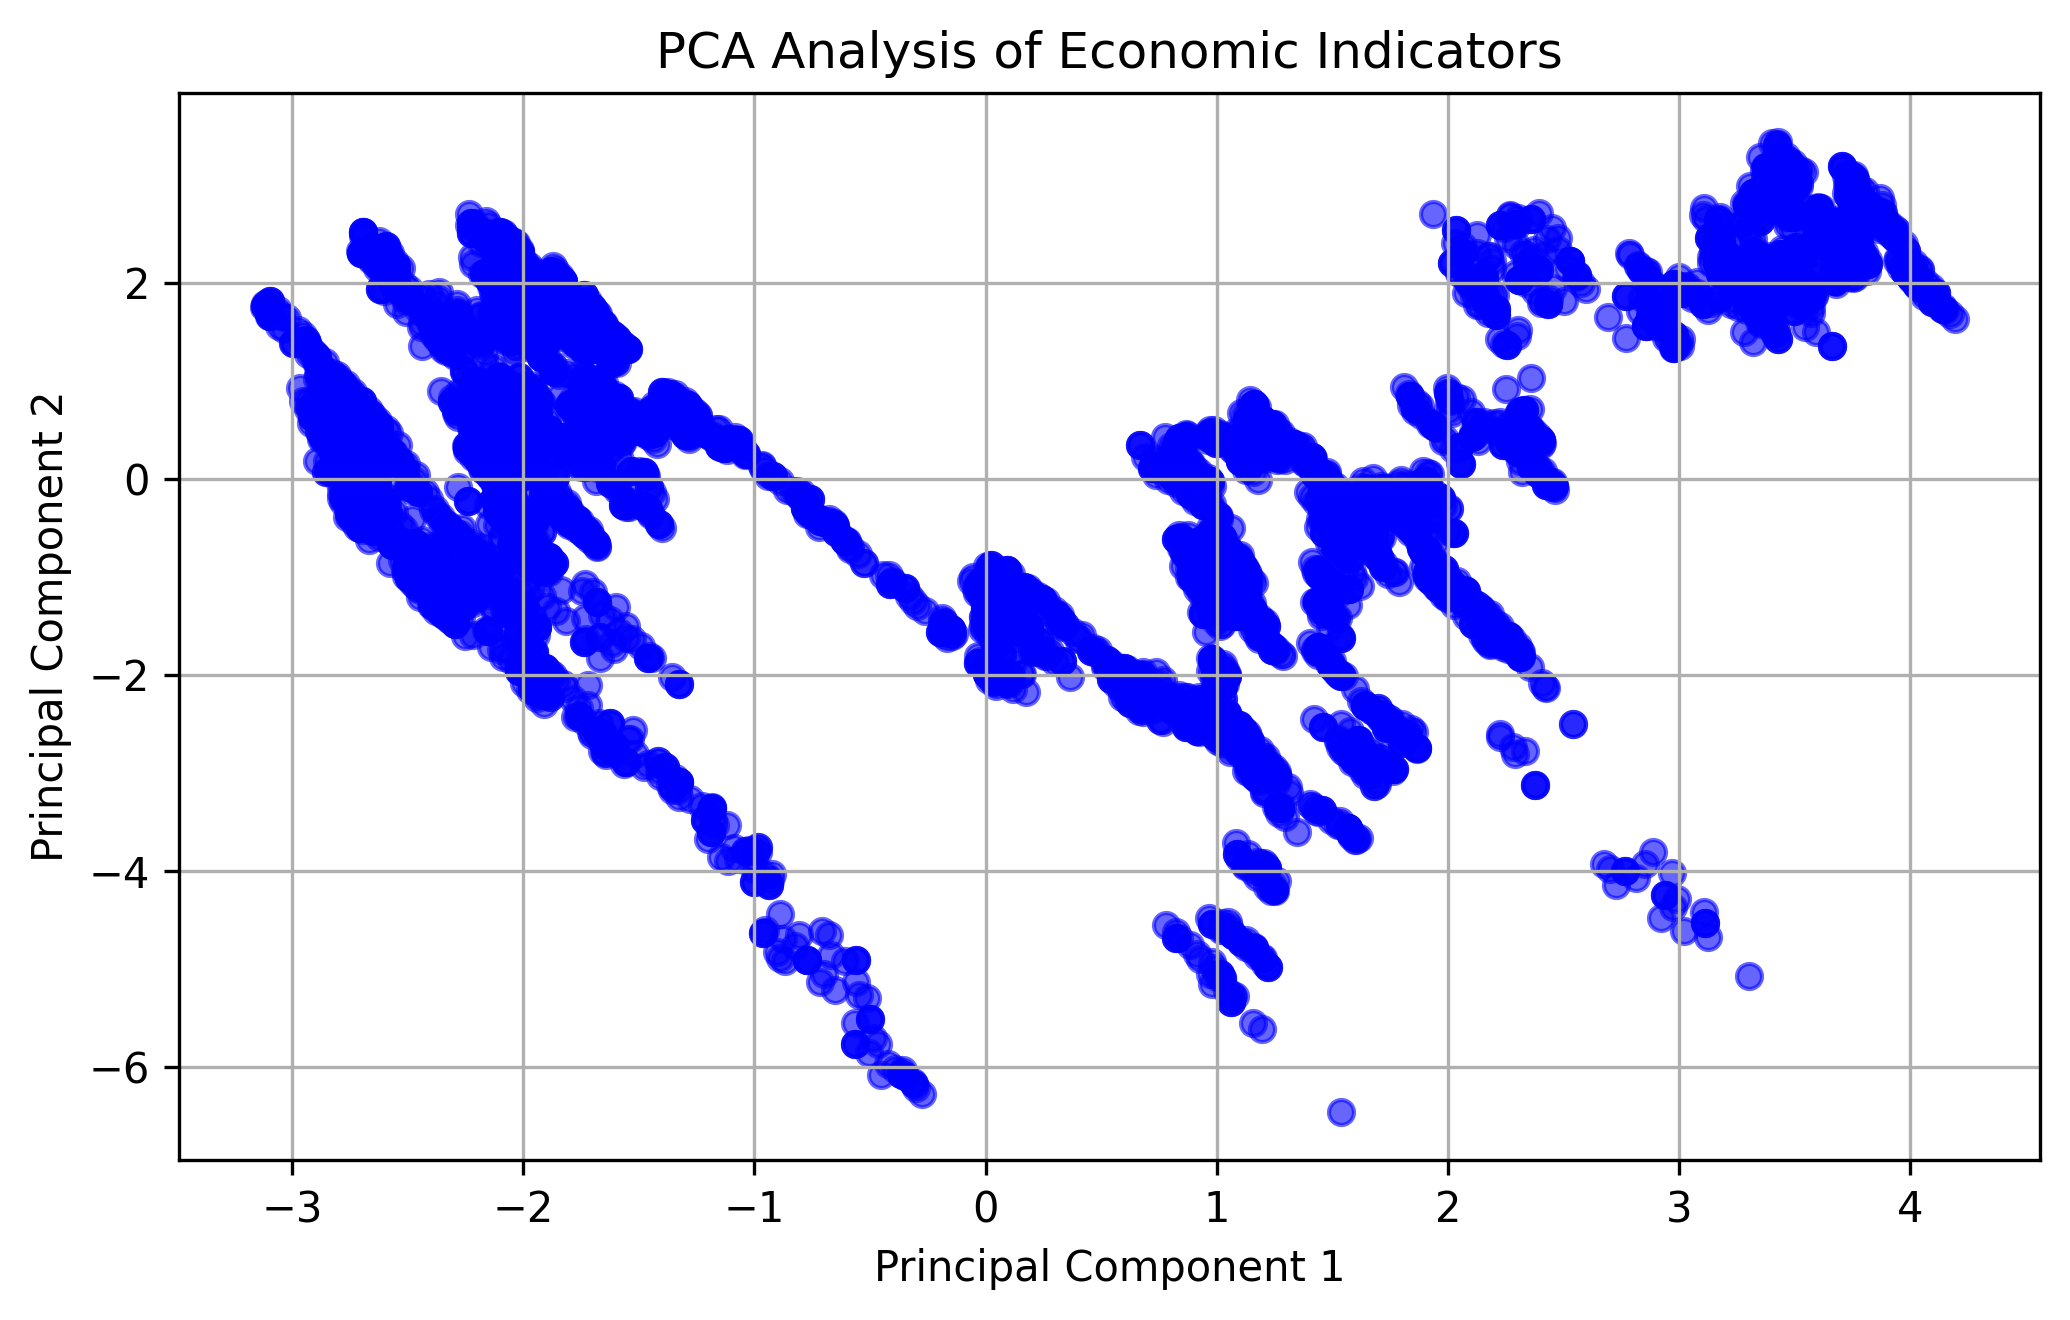

In [ ]:
# Define the list of economic indicators for PCA
economic_indicators = ['T10YIE', 'T5YIFR', 'CPIAUCNS', 'PCEPI', 'GDPC1', 'UNRATE', 'FEDFUNDS', 'DGS10', 'DTWEXBGS', 'DCOILWTICO']

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize the dataset
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[economic_indicators])

# Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

# Scatter plot of PCA components with the specified figure size and dpi
plt.figure(figsize=(7, 4.5), dpi=300)
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.6, color='blue')
plt.title("PCA Analysis of Economic Indicators")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

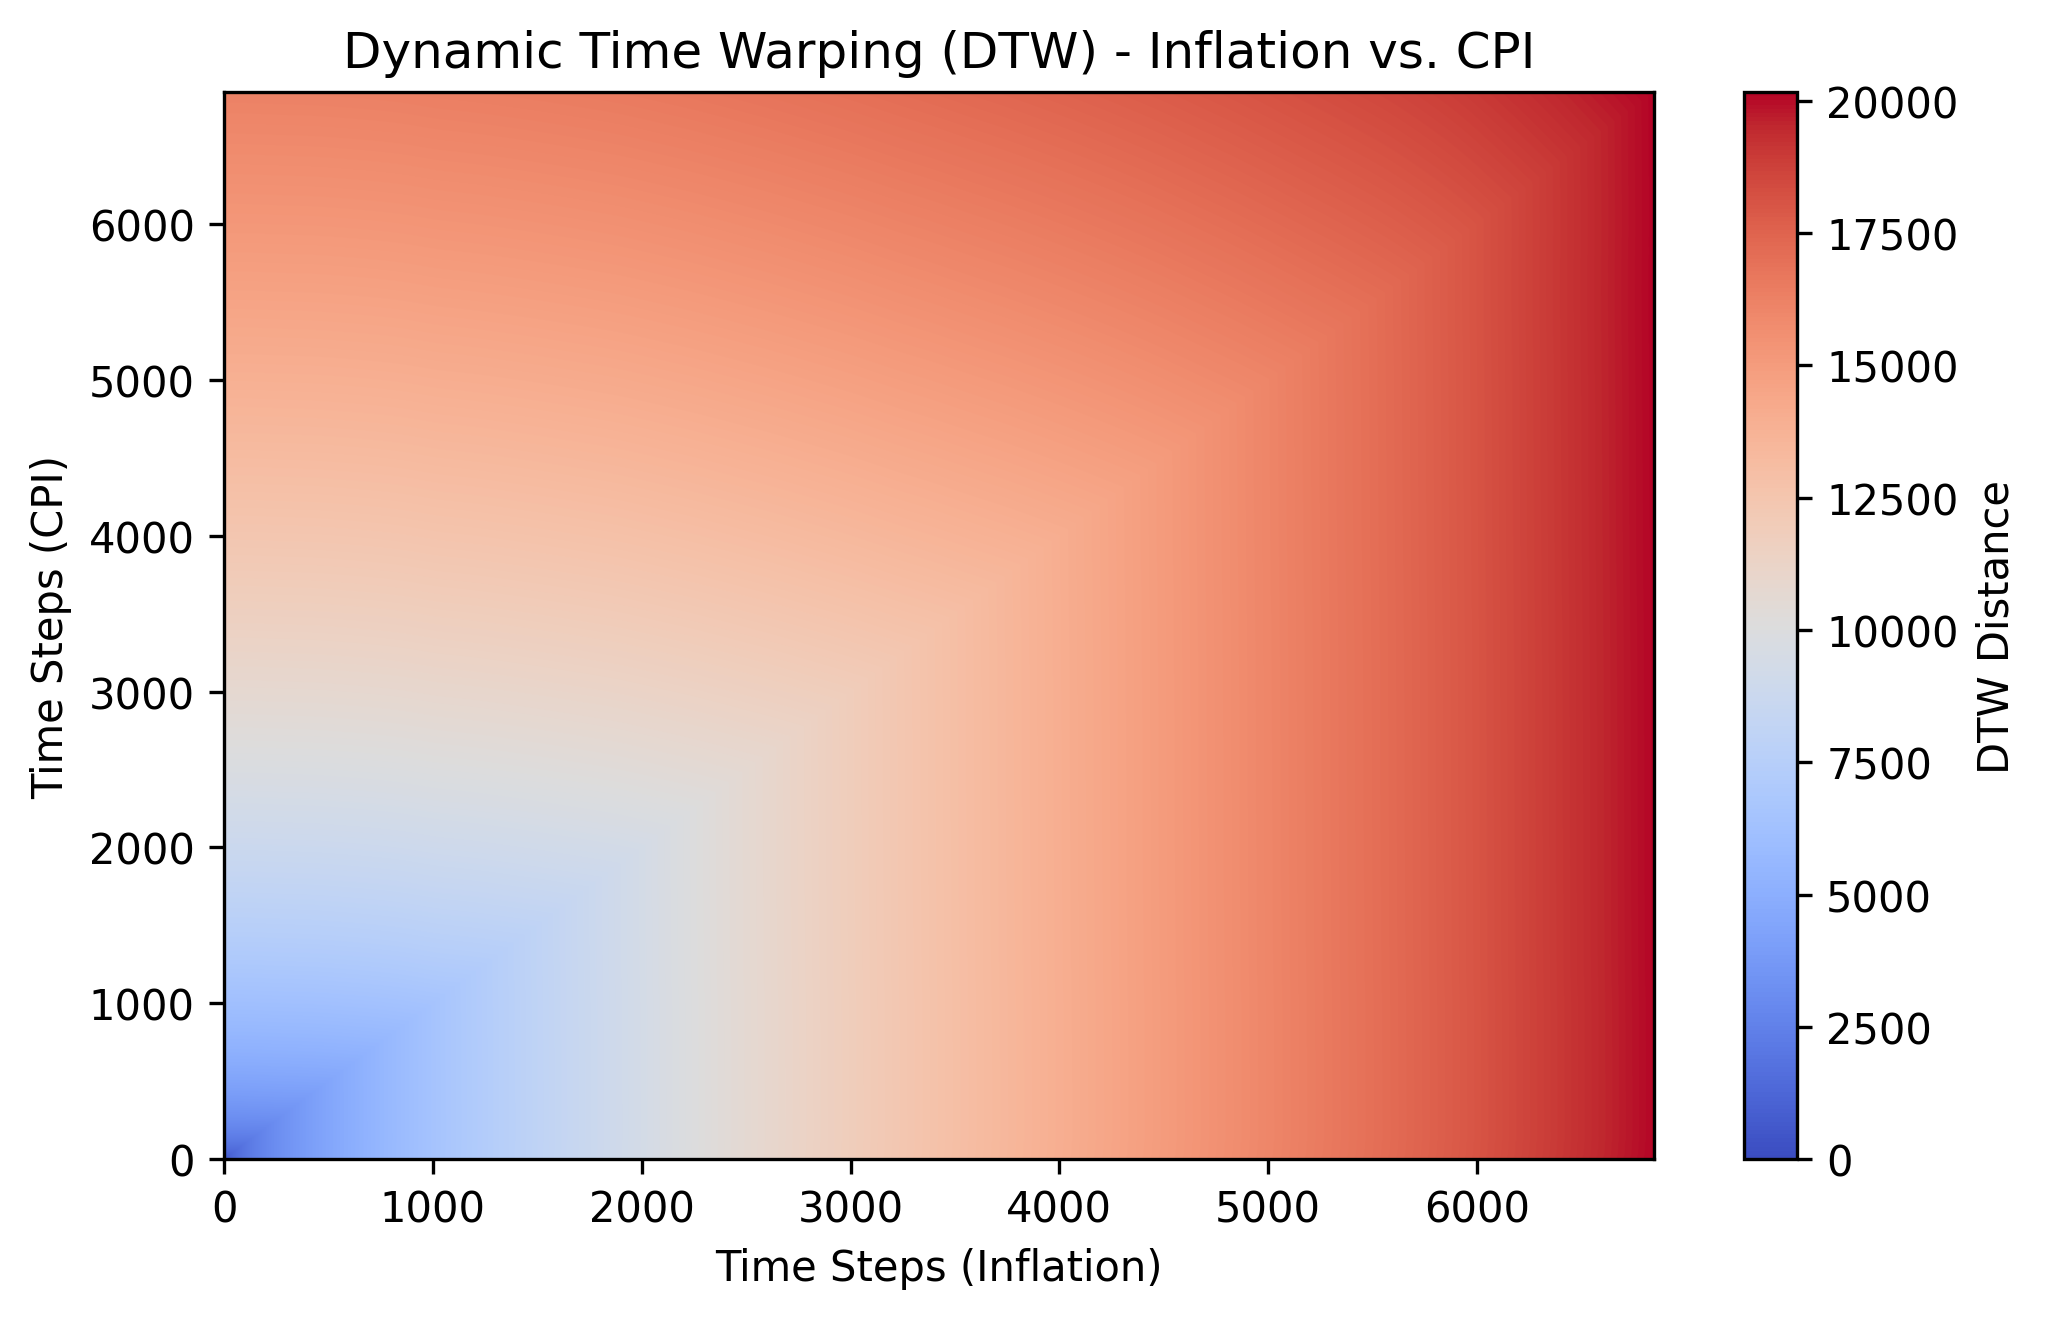

In [ ]:
# Dynamic Time Warping (DTW)
try:
    from dtaidistance import dtw
except ModuleNotFoundError:
    !pip install dtaidistance
    from dtaidistance import dtw

import numpy as np
import matplotlib.pyplot as plt

# Select two time-series to compare (CPI vs GDP)
series1 = df["T10YIE"].dropna().values
series2 = df["CPIAUCNS"].dropna().values

# Compute DTW warping paths (this returns a distance matrix)
_, paths = dtw.warping_paths(series1, series2)

# Convert paths to a NumPy array for visualization
distance_matrix = np.array(paths)

# Plot DTW distance matrix with the specified figure size and dpi
plt.figure(figsize=(7, 4.5), dpi=300)
plt.imshow(distance_matrix, aspect='auto', cmap='coolwarm', origin='lower')
plt.colorbar(label="DTW Distance")
plt.title("Dynamic Time Warping (DTW) - Inflation vs. CPI")
plt.xlabel("Time Steps (Inflation)")
plt.ylabel("Time Steps (CPI)")
plt.tight_layout()
plt.show()

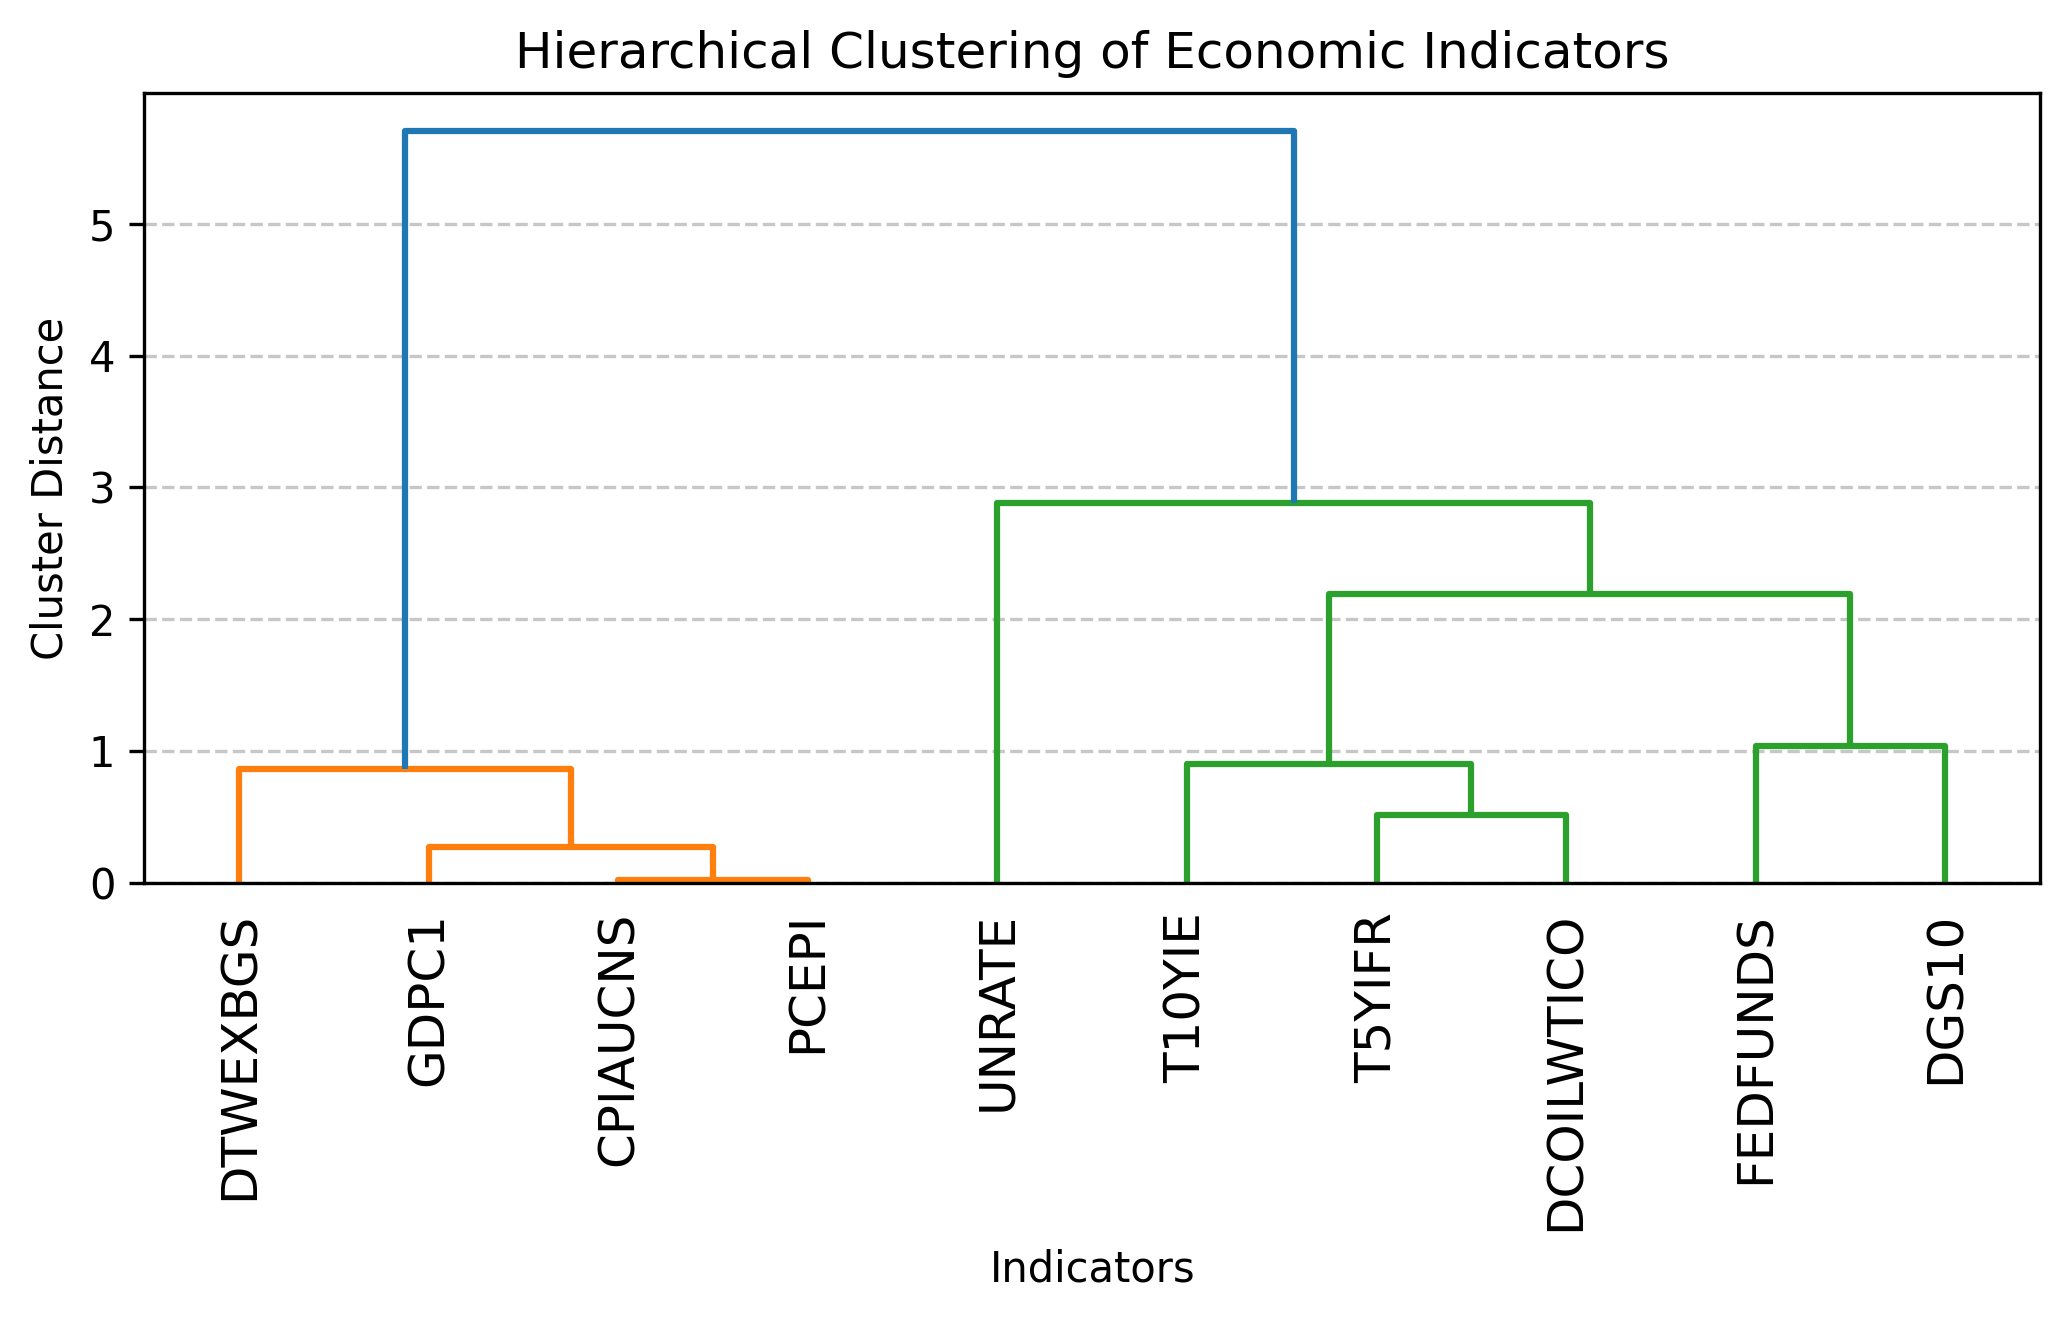

In [ ]:
import seaborn as sns
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage

# Select numeric columns only (ignoring the index)
df_numeric = df.dropna().select_dtypes(include=[np.number])

# Compute correlation matrix (since clustering is usually done on features, not observations)
corr_matrix = df_numeric.corr()

# Compute hierarchical clustering using the correlation matrix
linkage_matrix = sch.linkage(corr_matrix, method='ward')

# Plot the dendrogram with proper labels using the specified figure size and dpi
plt.figure(figsize=(7, 4.5), dpi=300)
dendrogram(linkage_matrix, labels=corr_matrix.columns, leaf_rotation=90)
plt.title("Hierarchical Clustering of Economic Indicators")
plt.xlabel("Indicators")
plt.ylabel("Cluster Distance")
plt.grid(axis="y", linestyle="dashed", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
!pip install adjustText

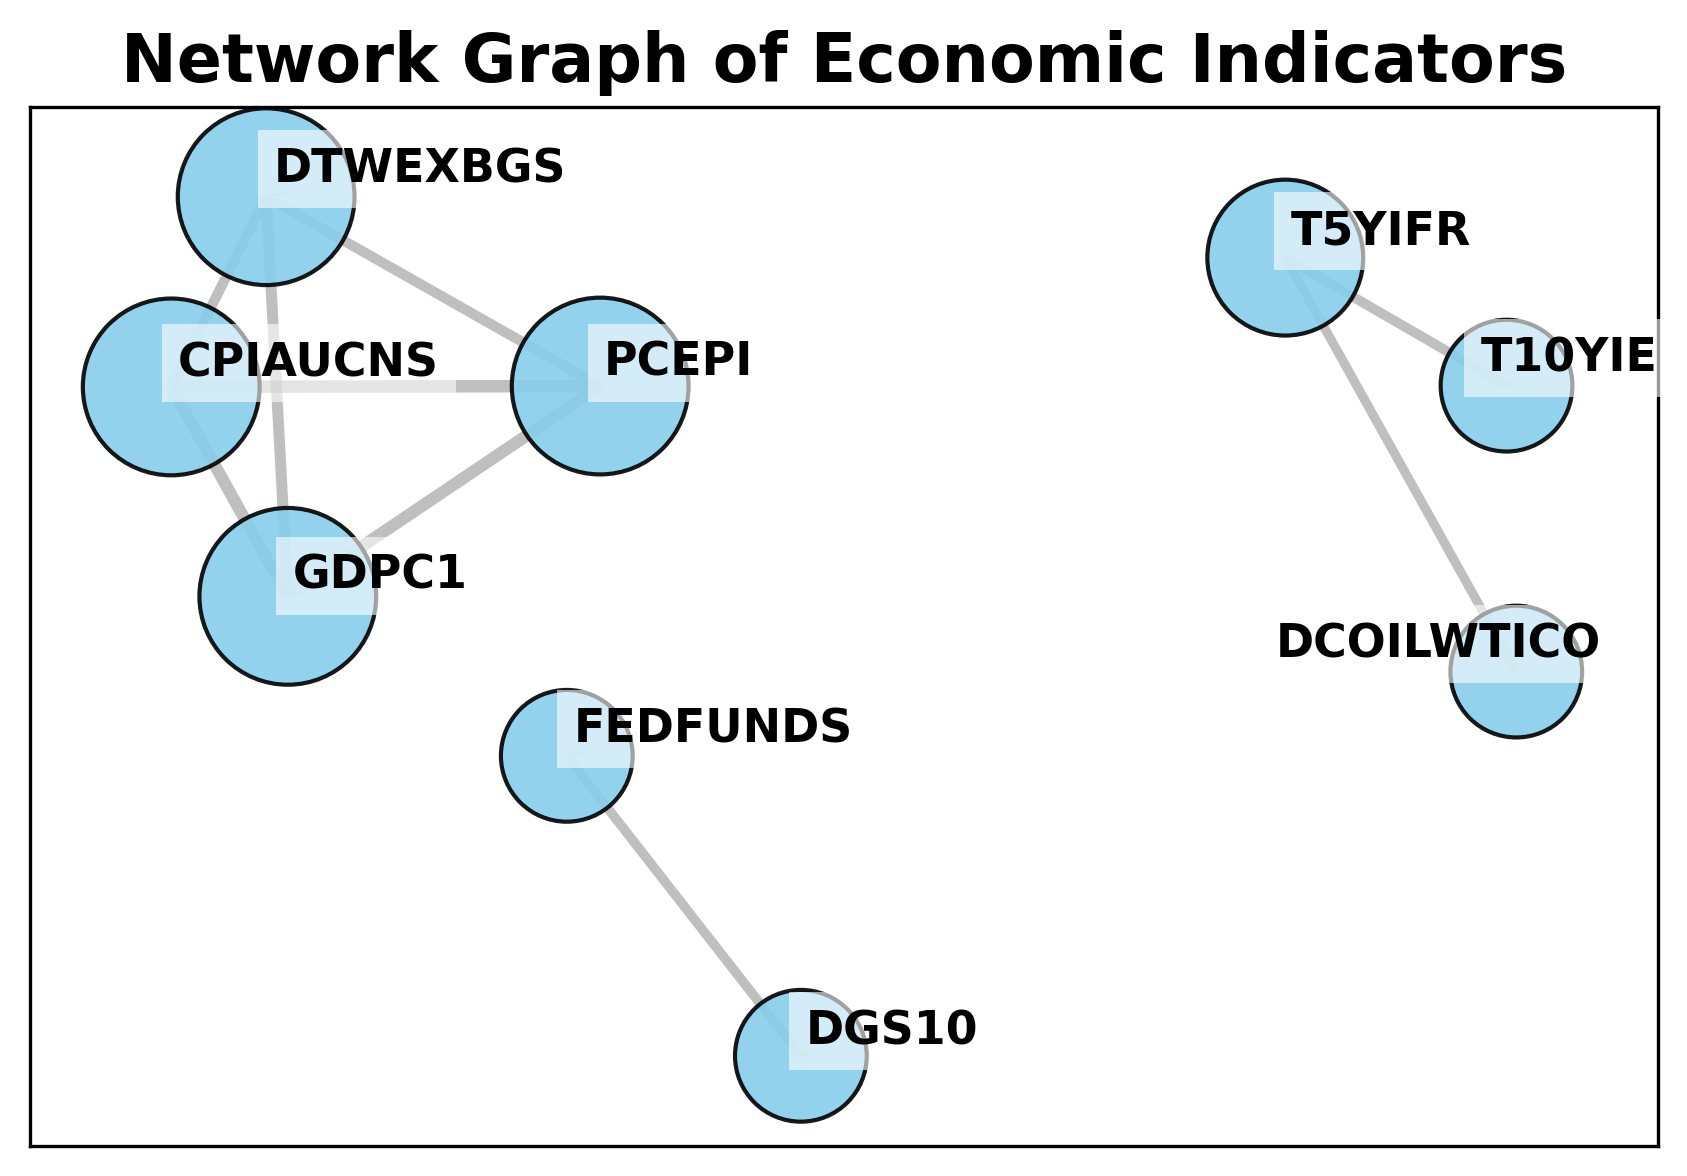

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text  # Automatically adjusts text positions
import numpy as np

# Compute correlation matrix using the original dataframe
corr_matrix = df.corr()

# Create a graph from strong correlations
G = nx.Graph()
threshold = 0.7  # Only add edges with strong correlations
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            G.add_edge(corr_matrix.columns[i], corr_matrix.columns[j], weight=corr_matrix.iloc[i, j])

# Generate node sizes based on connectivity (degree of connections)
node_sizes = [600 + (G.degree(n) * 400) for n in G.nodes()]  # Scaled appropriately

# Generate edge thickness based on correlation strength
edges = [(u, v) for u, v in G.edges()]
edge_weights = [abs(G[u][v]['weight']) * 3 for u, v in edges]  # Scale for visibility

# Use a spring layout with increased spacing
pos = nx.spring_layout(G, k=1.2, seed=42)

# Create the network plot with the specified figure size and dpi
plt.figure(figsize=(7, 4.5), dpi=300)

# Draw edges with varying thickness
nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color="gray", width=edge_weights)

# Draw nodes with size scaling
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.9, edgecolors="black")

# Draw labels with dynamic adjustment
texts = []
for node, (x, y) in pos.items():
    texts.append(plt.text(x, y, node, fontsize=11, fontweight="bold",
                          bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")))

# Automatically adjust text positions to prevent overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

# Add title
plt.title("Network Graph of Economic Indicators", fontsize=16, fontweight="bold")

# Show final network graph
plt.show()

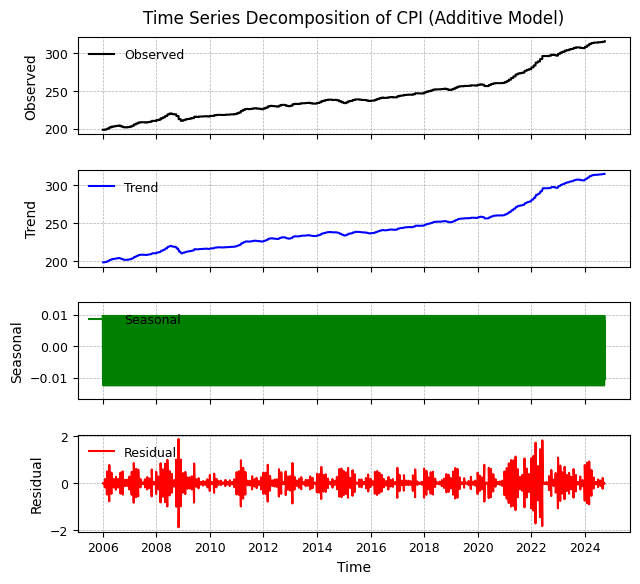

In [ ]:
# Time Series Decomposition (CPI)
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform time series decomposition
cpi_decomposed = seasonal_decompose(df["CPIAUCNS"].dropna(), model='additive', period=12)

# Create improved, publication-quality plot
fig, axes = plt.subplots(4, 1, figsize=(6.5, 6), sharex=True)

# Components and styling
components = ['Observed', 'Trend', 'Seasonal', 'Residual']
series = [cpi_decomposed.observed, cpi_decomposed.trend,
          cpi_decomposed.seasonal, cpi_decomposed.resid]
colors = ['black', 'blue', 'green', 'red']

for ax, label, data, color in zip(axes, components, series, colors):
    ax.plot(data, label=label, color=color, linewidth=1.5)
    ax.set_ylabel(label, fontsize=10)
    ax.tick_params(axis='both', labelsize=9)
    ax.legend(loc='upper left', fontsize=9, frameon=False)
    ax.grid(True, linestyle='--', linewidth=0.5)

    # Handle seasonal scale (optional manual limits if needed)
    if label == 'Seasonal':
        ymin, ymax = data.min(), data.max()
        margin = (ymax - ymin) * 0.2
        ax.set_ylim(ymin - margin, ymax + margin)

axes[0].set_title("Time Series Decomposition of CPI (Additive Model)", fontsize=12, pad=10)
axes[-1].set_xlabel("Time", fontsize=10)

plt.tight_layout(h_pad=2.0)
plt.subplots_adjust(top=0.92)
plt.show()

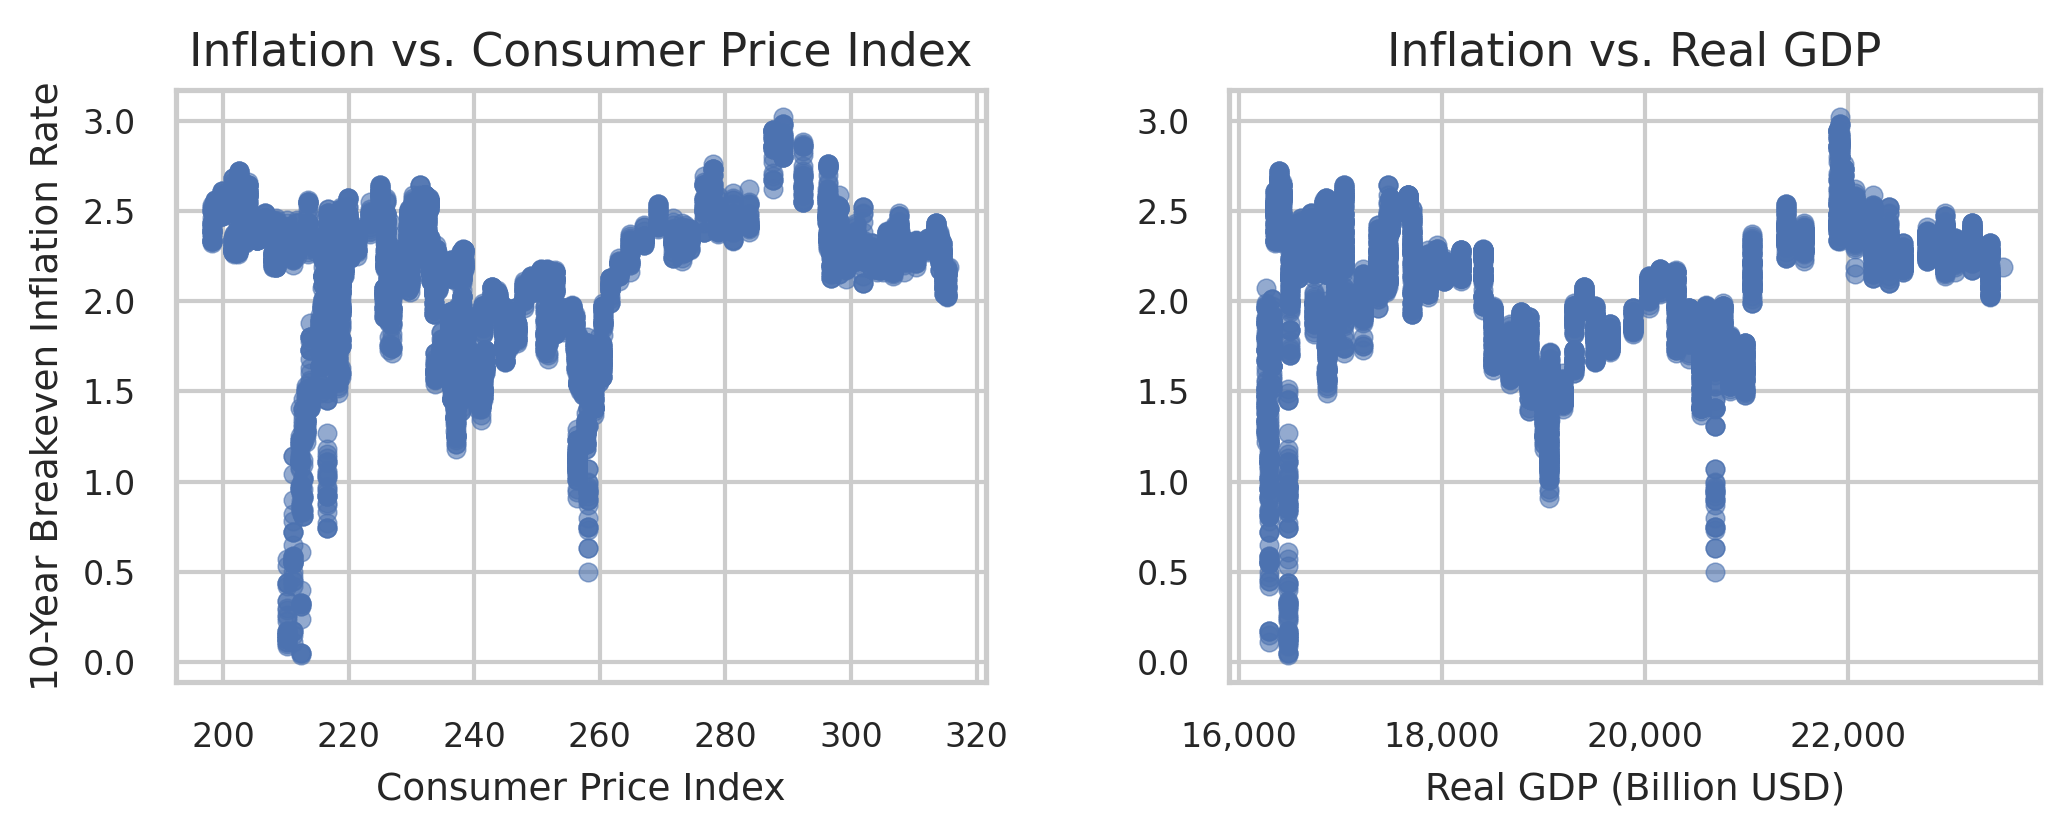

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Set aesthetic style
sns.set(style="whitegrid")

# Clean column names
df.columns = df.columns.str.strip()

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3), dpi=300)

# Define plots (CPI and GDP)
plots = [
    ("CPIAUCNS", "Inflation vs. Consumer Price Index", "Consumer Price Index"),
    ("GDPC1", "Inflation vs. Real GDP", "Real GDP (Billion USD)")
]

# Generate plots
for i, (x_col, title, x_label) in enumerate(plots):
    sns.scatterplot(
        x=df[x_col],
        y=df["T10YIE"],
        ax=axes[i],
        alpha=0.6,
        edgecolor=None,
        s=20
    )
    axes[i].set_title(title, fontsize=11)
    axes[i].set_xlabel(x_label, fontsize=9)
    axes[i].tick_params(axis='both', labelsize=8)

    # Improve GDP axis formatting
    if x_col == "GDPC1":
        axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        axes[i].xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

    # Set y-axis label only on the first plot
    if i == 0:
        axes[i].set_ylabel("10-Year Breakeven Inflation Rate", fontsize=9)
    else:
        axes[i].set_ylabel("")

# Layout and spacing
plt.tight_layout(pad=1.5)
plt.subplots_adjust(wspace=0.3, top=0.88)

# Optional: Save the figure
# fig.savefig("inflation_vs_cpi_gdp_final.pdf", dpi=300, bbox_inches="tight")

# Display
plt.show()


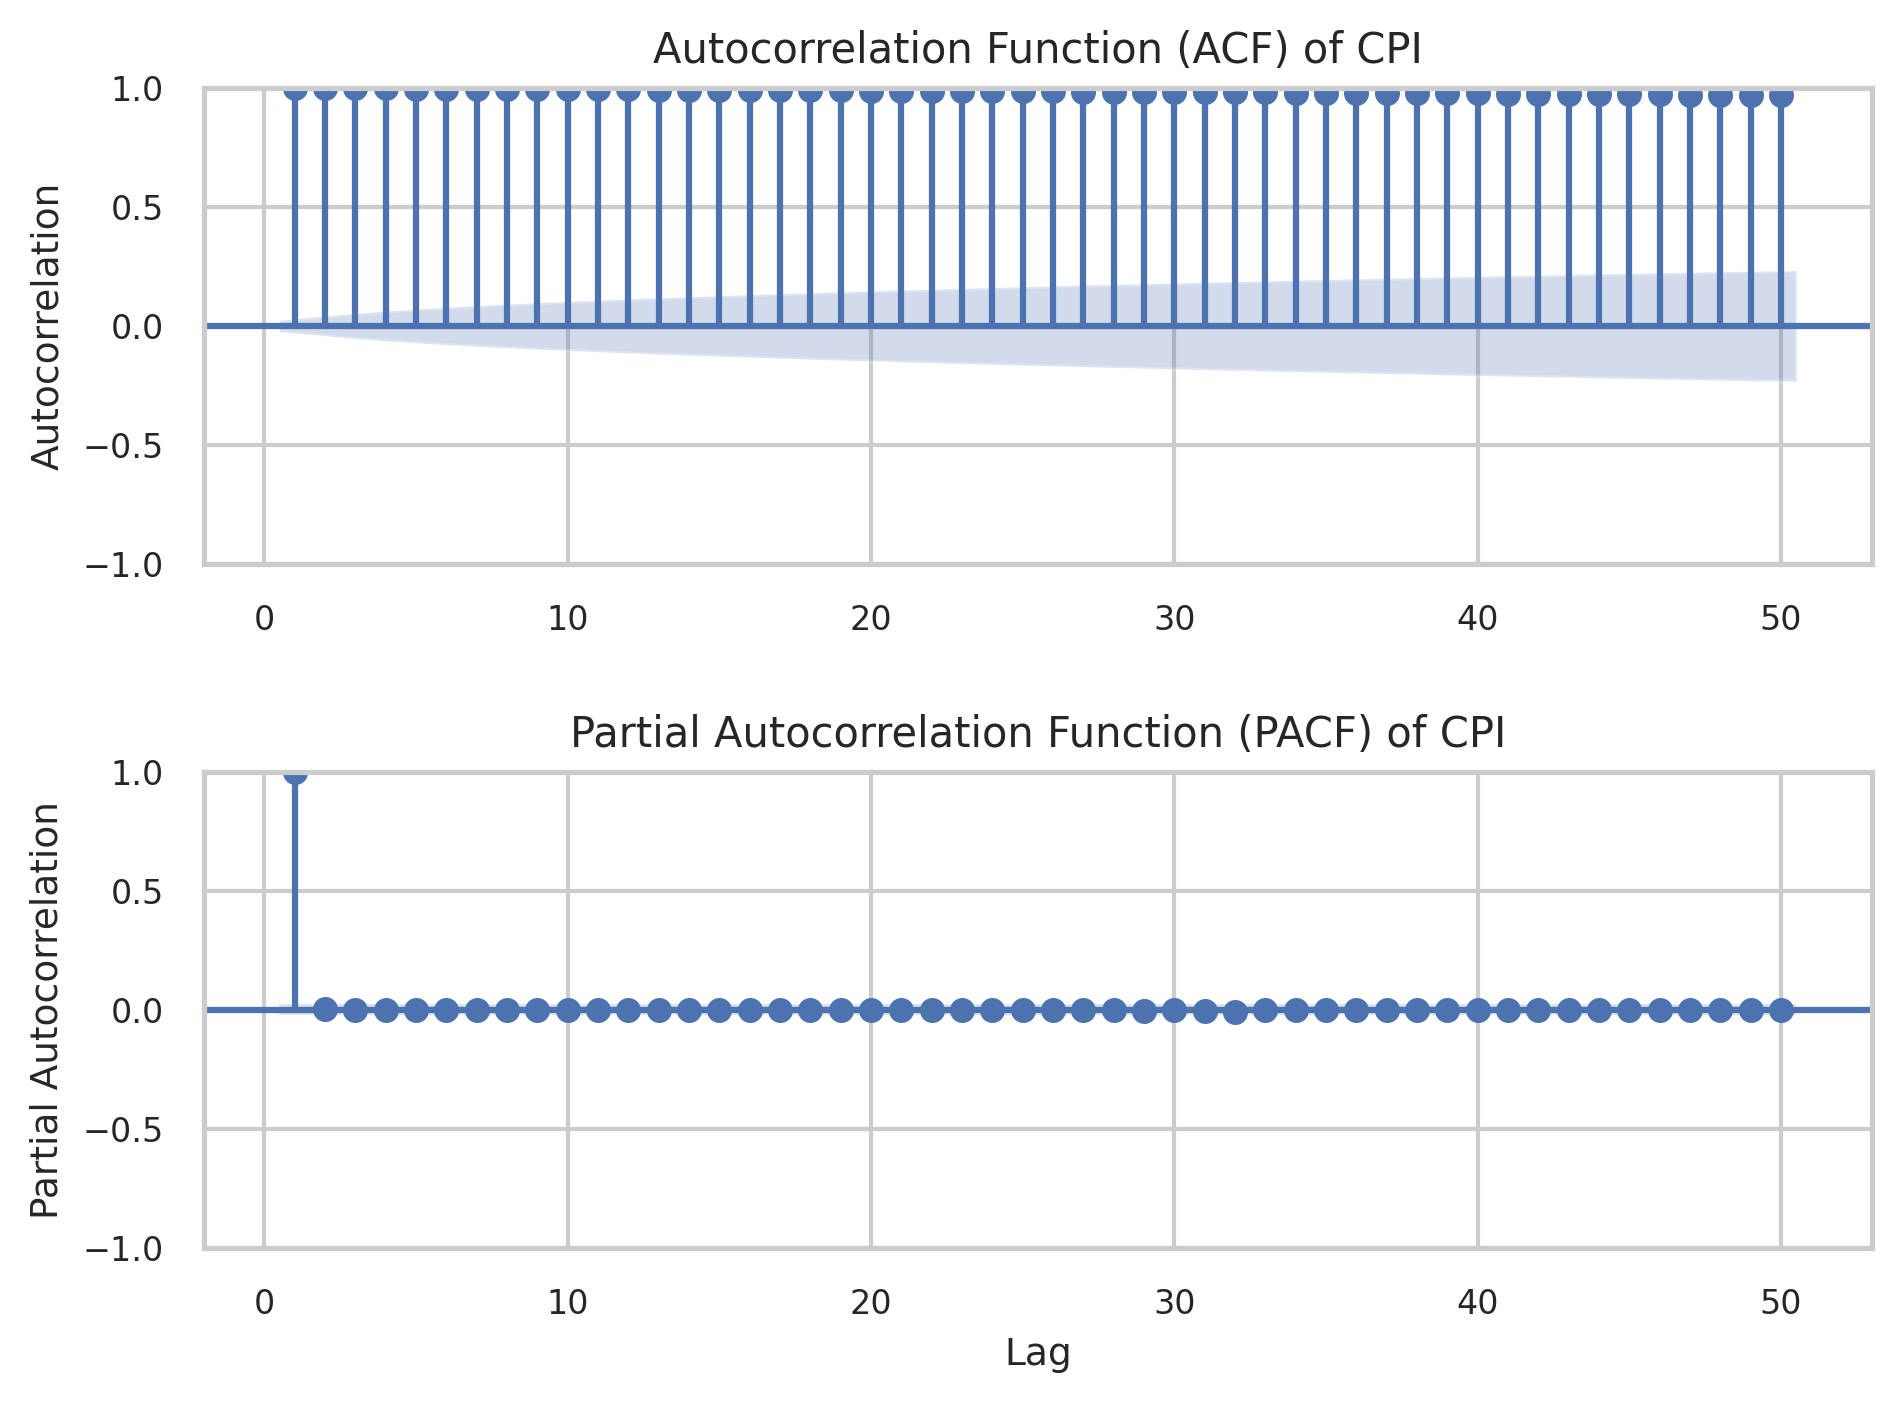

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set CPI column name correctly
df.columns = df.columns.str.strip()

# Create ACF and PACF plots with journal-friendly formatting
fig, ax = plt.subplots(2, 1, figsize=(6.5, 4.8), dpi=300)  # Journal column width

# ACF Plot
plot_acf(df["CPIAUCNS"].dropna(), lags=50, ax=ax[0], zero=False)
ax[0].set_title("Autocorrelation Function (ACF) of CPI", fontsize=10)
ax[0].set_ylabel("Autocorrelation", fontsize=9)
ax[0].tick_params(axis='both', labelsize=8)

# PACF Plot
plot_pacf(df["CPIAUCNS"].dropna(), lags=50, ax=ax[1], zero=False, method='ywm')
ax[1].set_title("Partial Autocorrelation Function (PACF) of CPI", fontsize=10)
ax[1].set_xlabel("Lag", fontsize=9)
ax[1].set_ylabel("Partial Autocorrelation", fontsize=9)
ax[1].tick_params(axis='both', labelsize=8)

# Tight layout and spacing
plt.tight_layout(h_pad=1.5)
plt.subplots_adjust(top=0.93)

# Optional: Save figure
# fig.savefig("acf_pacf_cpi.png", dpi=300, bbox_inches="tight")

plt.show()